---
title: Cloud Storage & Profiling Statistik Data (Aiven - KNIME)
---

## Pendahuluan

### Review Tugas 1

#### Mengapa Perlu Melakukan Review Tugas 1?

Pengerjaan Tugas 2 memiliki hubungan langsung (*continuity*) dan merupakan kelanjutan dari hasil yang telah diperoleh pada Tugas 1. Dalam metodologi standar penambangan data **CRISP-DM (*Cross-Industry Standard Process for Data Mining*)**, alur kerja data science bergerak secara bertahap dari pemahaman bisnis (*Business Understanding*) dan pemahaman data (*Data Understanding*) menuju tahap penyiapan data (*Data Preparation*). 

Data mentah kualitas udara yang telah dikumpulkan, dieksplorasi, dan diekspor pada Tugas 1 akan menjadi masukan (*input*) utama pada Tugas 2. Oleh karena itu, *review* terhadap Tugas 1 sangat esensial untuk:

1. Mengingat kembali konteks wilayah, periode waktu, serta parameter kualitas udara yang diamati.
2. Memahami karakteristik, struktur kolom, dan transformasi awal (*rolling mean*) yang telah diterapkan pada dataset.
3. Memastikan keselarasan tujuan sebelum data tersebut dimigrasikan ke infrastruktur *cloud database* (Aiven) dan dianalisis profil statistiknya menggunakan KNIME Analytics Platform.

#### Ringkasan Pengerjaan dan Hasil Tugas 1

Pada Tugas 1 yang berjudul **"Data Crawling & Data Understanding (OpenEO - Sentinel-5P)"**, telah diselesaikan beberapa tahapan utama sebagai berikut:

1. **Tahap *Business Understanding*:**
   - **Pemahaman Konsep AQI & Polutan**: Mempelajari indeks kualitas udara (*Air Quality Index*) dan 6 parameter gas atmosfer utama yang disediakan oleh instrumen TROPOMI pada satelit **Sentinel-5P *Level-2***, yaitu:
     - **CO** (*Carbon Monoxide* / Karbon Monoksida)
     - **HCHO** (*Formaldehyde* / Formaldehida)
     - **NO2** (*Nitrogen Dioxide* / Nitrogen Dioksida)
     - **O3** (*Ozone* / Ozon)
     - **SO2** (*Sulphur Dioxide* / Sulfur Dioksida)
     - **CH4** (*Methane* / Metana)
   - **Penetapan Sasaran Pengamatan**: Menetapkan tujuan pemantauan tren kualitas udara di area tempat tinggal penulis (wilayah Surabaya–Sidoarjo) selama rentang waktu 1 tahun (24 Agustus 2025 hingga 24 Agustus 2026).

2. **Tahap *Data Understanding* & *Data Crawling*:**
   - **Autentikasi & Koneksi OpenEO**: Terhubung ke backend platform satelit *Copernicus OpenEO Data Space Ecosystem* (`openeo.dataspace.copernicus.eu`) menggunakan standar *OpenID Connect* (OIDC).
   - **Konfigurasi Wilayah (AOI)**: Menentukan poligon geografis *Area of Interest* (AOI) dalam format GeoJSON Polygon dan *spatial extent* (batas koordinat lintang dan bujur) tempat tinggal penulis.
   - **Pemrosesan Data Cube di Cloud**: Memuat koleksi data `SENTINEL_5P_L2` untuk keenam band polutan secara perulangan, menerapkan agregasi temporal harian (`aggregate_temporal_period`), menggabungkan kubus data (`merge_cubes`), dan melakukan agregasi spasial rata-rata terhadap geometri AOI (`aggregate_spatial`).
   - **Eksekusi Batch Job & Unduh NetCDF**: Menjalankan *batch job* pemrosesan di cloud OpenEO dan mengunduh berkas hasil akhir dalam format NetCDF (`kualitas_udara_sentinel5p.nc`).

3. **Eksplorasi Data & Prapemrosesan Awal:**
   - **Penghalusan Data (*Data Smoothing*)**: Menerapkan teknik rata-rata bergerak (*rolling mean* 30 hari) pada dataset `xarray` untuk mereduksi fluktuasi tajam harian (*noise*) akibat variasi cuaca atau tutupan awan.
   - **Pembersihan & Ekspor Data Tabular**: Menghapus fitur indeks dan koordinat statis yang redundan (`feature`, `lat`, `lon`, `feature_names`), menyelaraskan nama kolom indeks waktu menjadi `date`, dan mengekspor dataset ke dalam berkas `data_kualitas_udara.csv` dengan struktur kolom: `date`, `CO`, `HCHO`, `NO2`, `O3`, `SO2`, dan `CH4`.
   - **Visualisasi Deret Waktu & Spasial**: Membuat grafik kartesius (*line plot*) deret waktu untuk masing-masing polutan serta memvisualisasikan sebaran spasial polusi menggunakan peta interaktif *heatmap* berbasis *library* `folium`.

### Aiven


#### Apa itu Aiven?

[Aiven](https://aiven.io) adalah platform *Data Cloud Management* (*Data Platform as a Service*) yang menyediakan dan mengelola berbagai layanan basis data serta infrastruktur data *open-source* populer (seperti PostgreSQL, MySQL, Apache Kafka, OpenSearch, ClickHouse, dan Redis) secara terkelola penuh (*fully managed*). Aiven memungkinkan pengguna untuk meluncurkan database cloud di berbagai penyedia infrastruktur *cloud provider* terkemuka dunia, seperti Google Cloud Platform (GCP), Amazon Web Services (AWS), dan Microsoft Azure.

#### Fungsi dan Manfaat Aiven

Beberapa fungsi dan keunggulan utama Aiven dalam proyek data sains:
1. **Penyedia Layanan Database Terkelola (*Fully Managed Database*)**: Mengotomatiskan proses *deployment*, pemeliharaan, pencadangan (*backup* otomatis), pembaruan sistem, hingga keamanan database tanpa perlu konfigurasi server fisik manual.
2. **Aksesibilitas dan Integrasi Cloud**: Memungkinkan database (misalnya PostgreSQL atau MySQL) diakses secara aman dari berbagai alat analitik, ETL tools, maupun bahasa pemrograman melalui koneksi internet publik dengan enkripsi SSL/TLS.
3. **Skalabilitas Mudah**: Memudahkan penyesuaian kapasitas komputasi (*CPU*, *RAM*) dan ruang penyimpanan (*storage*) sesuai kebutuhan beban kerja data.
4. **Efisiensi Kolaborasi Tim**: Menyediakan *dashboard* berbasis web yang intuitif untuk memantau status performa, log query, dan konfigurasi pengguna/kredensial database secara terpusat.

Untuk informasi lebih lanjut dan pembuatan akun/layanan database cloud, Anda dapat mengunjungi situs resmi [Aiven](https://aiven.io).

### KNIME


#### Apa itu KNIME?
[KNIME](https://knime.com) (*Konstanz Information Miner*) adalah platform analitik data, pelaporan, dan integrasi *open-source* berbasis grafis (*visual workflow/drag-and-drop*) yang dirancang untuk kebutuhan sains data, rekayasa data (*data engineering*), pembersihan data (*data preparation/ETL*), hingga pemodelan *machine learning*. KNIME memungkinkan praktisi data membangun alur kerja pemrosesan data ujung-ke-ujung (*end-to-end data pipeline*) secara modular tanpa harus menulis kode program dari awal (*low-code/no-code environment*).

#### Fungsi dan Manfaat KNIME
Beberapa fungsi utama KNIME dalam analisis dan pengolahan data:
1. **Pembersihan dan Transformasi Data (*Data Cleaning & ETL*)**: Menyediakan modul (*nodes*) lengkap untuk filtering baris/kolom, penanganan nilai kosong (*missing values*), manipulasi tipe data, normalisasi, agregasi, hingga *merging* dan *joining* tabel.
2. **Profiling Statistik Data (*Data Profiling*)**: Menganalisis distribusi data, statistik deskriptif (mean, median, standar deviasi, kuartil), matriks korelasi antar variabel, serta mendeteksi nilai ekstrim/outlier secara otomatis dan interaktif.
3. **Konektivitas Database yang Luas**: Terhubung dengan lancar ke berbagai sumber data, termasuk basis data cloud (melalui JDBC driver untuk PostgreSQL/MySQL di Aiven), file lokal (CSV, Excel, Parquet), hingga layanan cloud storage.
4. **Visualisasi dan Eksplorasi Data**: Menyediakan berbagai node visualisasi bawaan (seperti histogram, scatter plot, box plot, bar chart, dan line plot) untuk memahami pola persebaran atribut data.
5. **Dukungan Machine Learning & Ekstensibilitas**: Memiliki integrasi bawaan dengan library pemodelan prediktif serta dapat diperluas dengan skrip Python atau R jika diperlukan operasi kustom.

Untuk mengunduh dan mempelajari fitur-fitur KNIME Analytics Platform lebih lanjut, Anda dapat mengunjungi website resmi [KNIME](https://knime.com).

## Apa yang Akan Dilakukan Sekarang?

- Memindahkan data CSV yang dihasilkan dari tugas ke-1, ke Database Cloud (Aiven)
- Menyambungkan Aiven dengan DB Manager lokal
- Menampilkan statistika dari data yang telah diupload ke Aiven menggunakan software KNIME.
- Mengidentifikasi lalu menjelaskan properti-properti dari statistik yang dihasilkan oleh KNIME, seperti:
    - Column
    - Min
    - Max
    - Mean
    - Median
    - Std. Dev.
    - Dll
- Memberi contoh perhitungan dari properti-properti yang ada (yang memungkinkan untuk dihitung), seperti:
    - Mean
    - Median
    - Std. Dev.
    - Kurtosis
    - Skewness

## Proses Pemindahan Data CSV ke Database Cloud (Via Aiven)

Proses pemindahan data kualitas udara dari berkas CSV lokal ke infrastruktur basis data cloud dilakukan melalui tiga tahapan utama: pembuatan layanan database terkelola di **Aiven**, konfigurasi koneksi menggunakan Database Manager lokal (**DBeaver**), dan proses impor dataset tabular ke tabel PostgreSQL.

---

### 1. Pembuatan Layanan (*Service*) Database PostgreSQL di Aiven

1. **Mengakses Situs Resmi Aiven**  
   Buka peramban web dan kunjungi laman [https://aiven.io](https://aiven.io).

   > 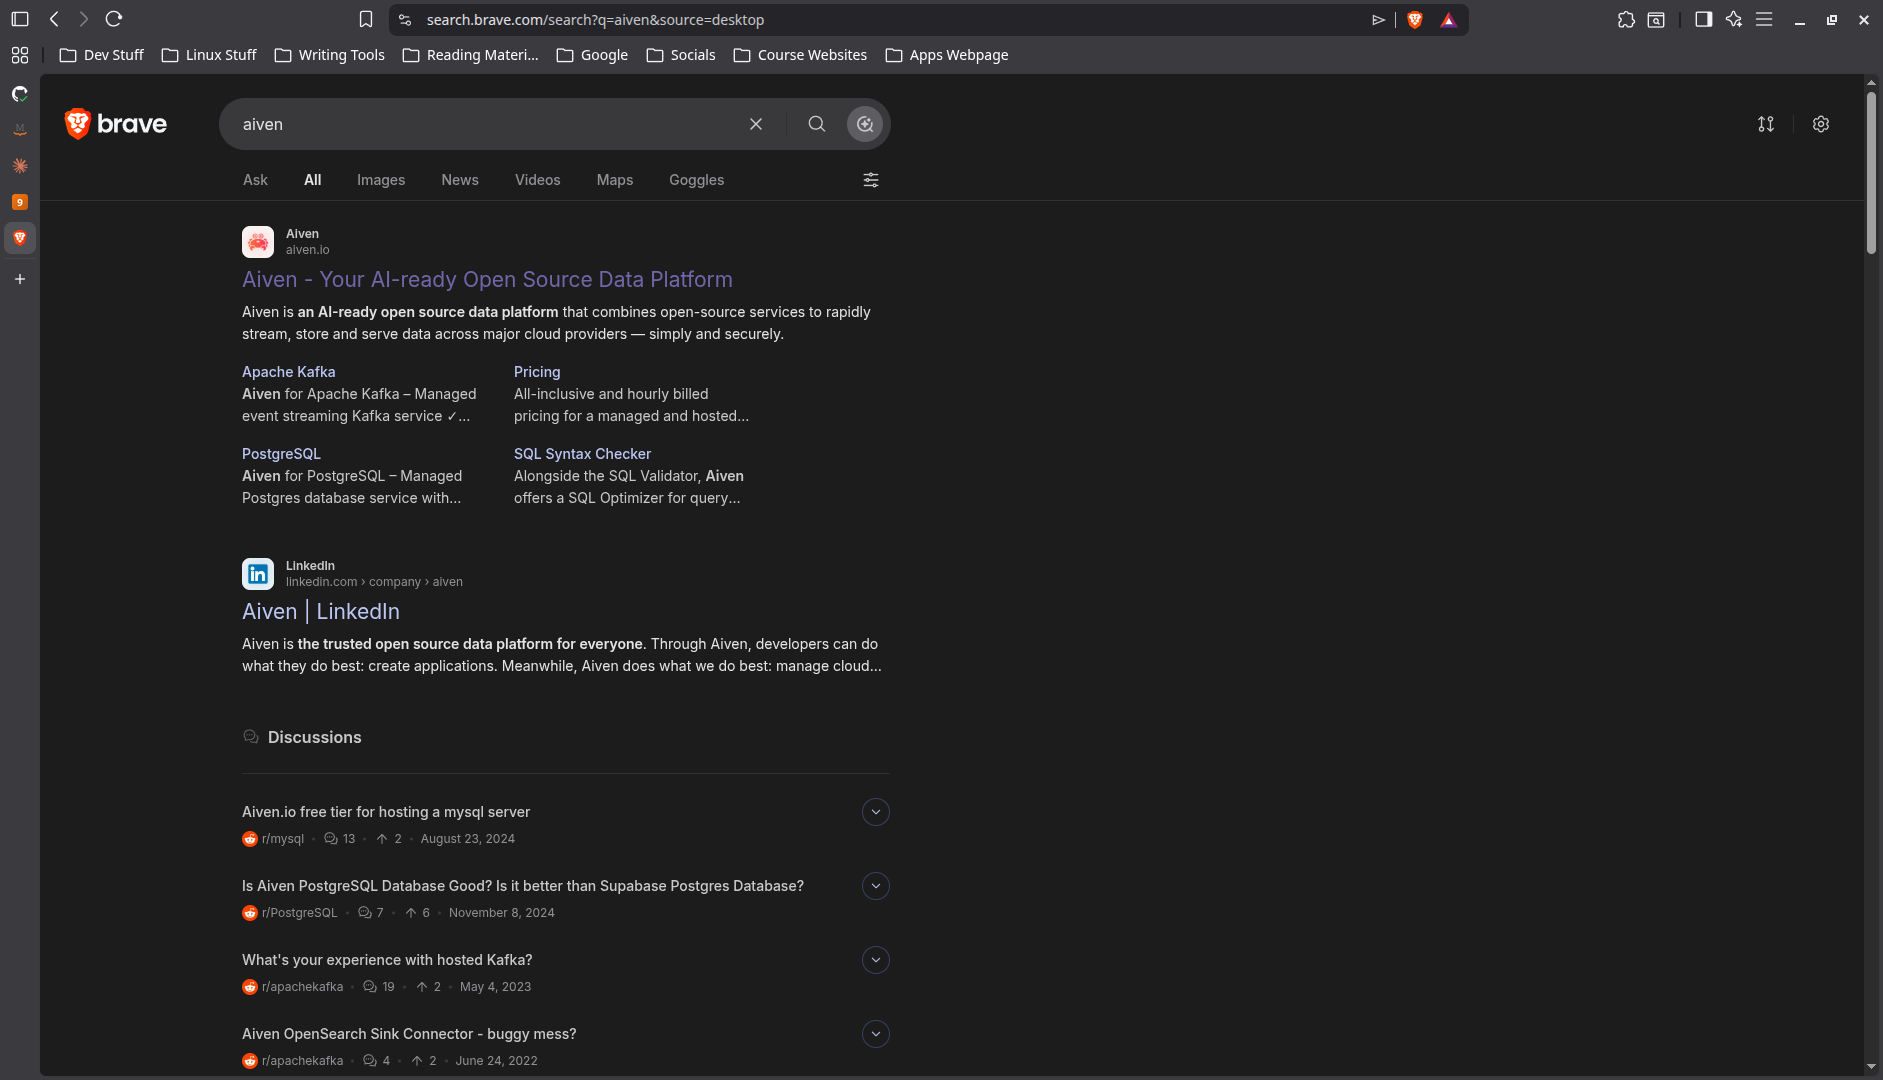

2. **Memilih Produk PostgreSQL**  
   Pada halaman utama atau katalog produk Aiven, pilih opsi produk **PostgreSQL** sebagai sistem basis data relasional (*RDBMS*) yang akan digunakan.

   > 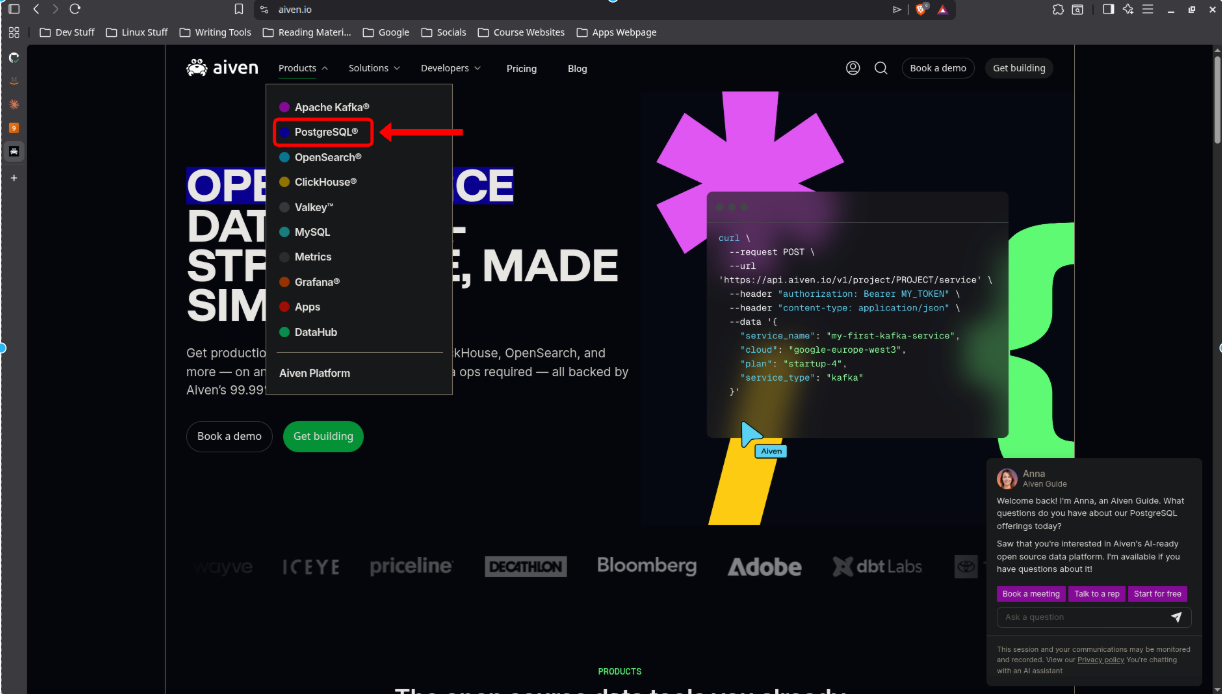

3. **Memulai Pembuatan Layanan (*Get Building*)**  
   Klik tombol **"Get Building"** atau **"Try for free"** untuk melanjutkan ke proses pendaftaran/pembuatan instance database.

   > 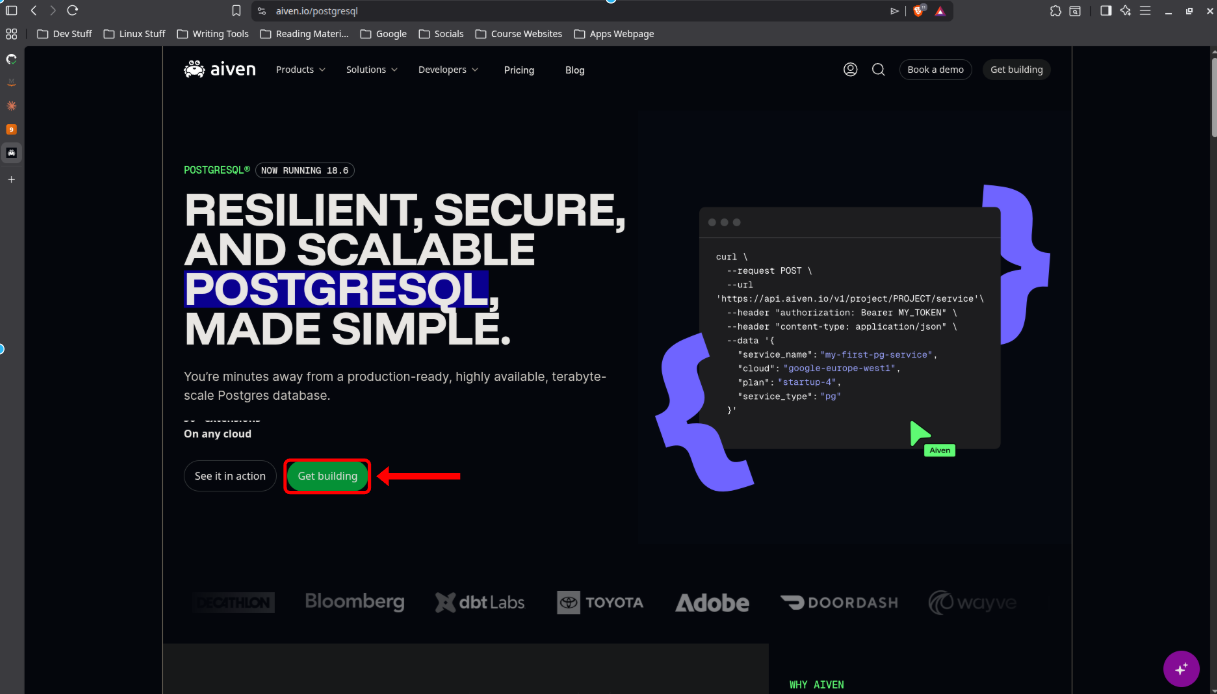

4. **Autentikasi dan Login Akun**  
   Masuk ke akun Aiven yang telah terdaftar menggunakan kredensial email atau penyedia autentikasi terintegrasi (seperti Google/GitHub).

   > 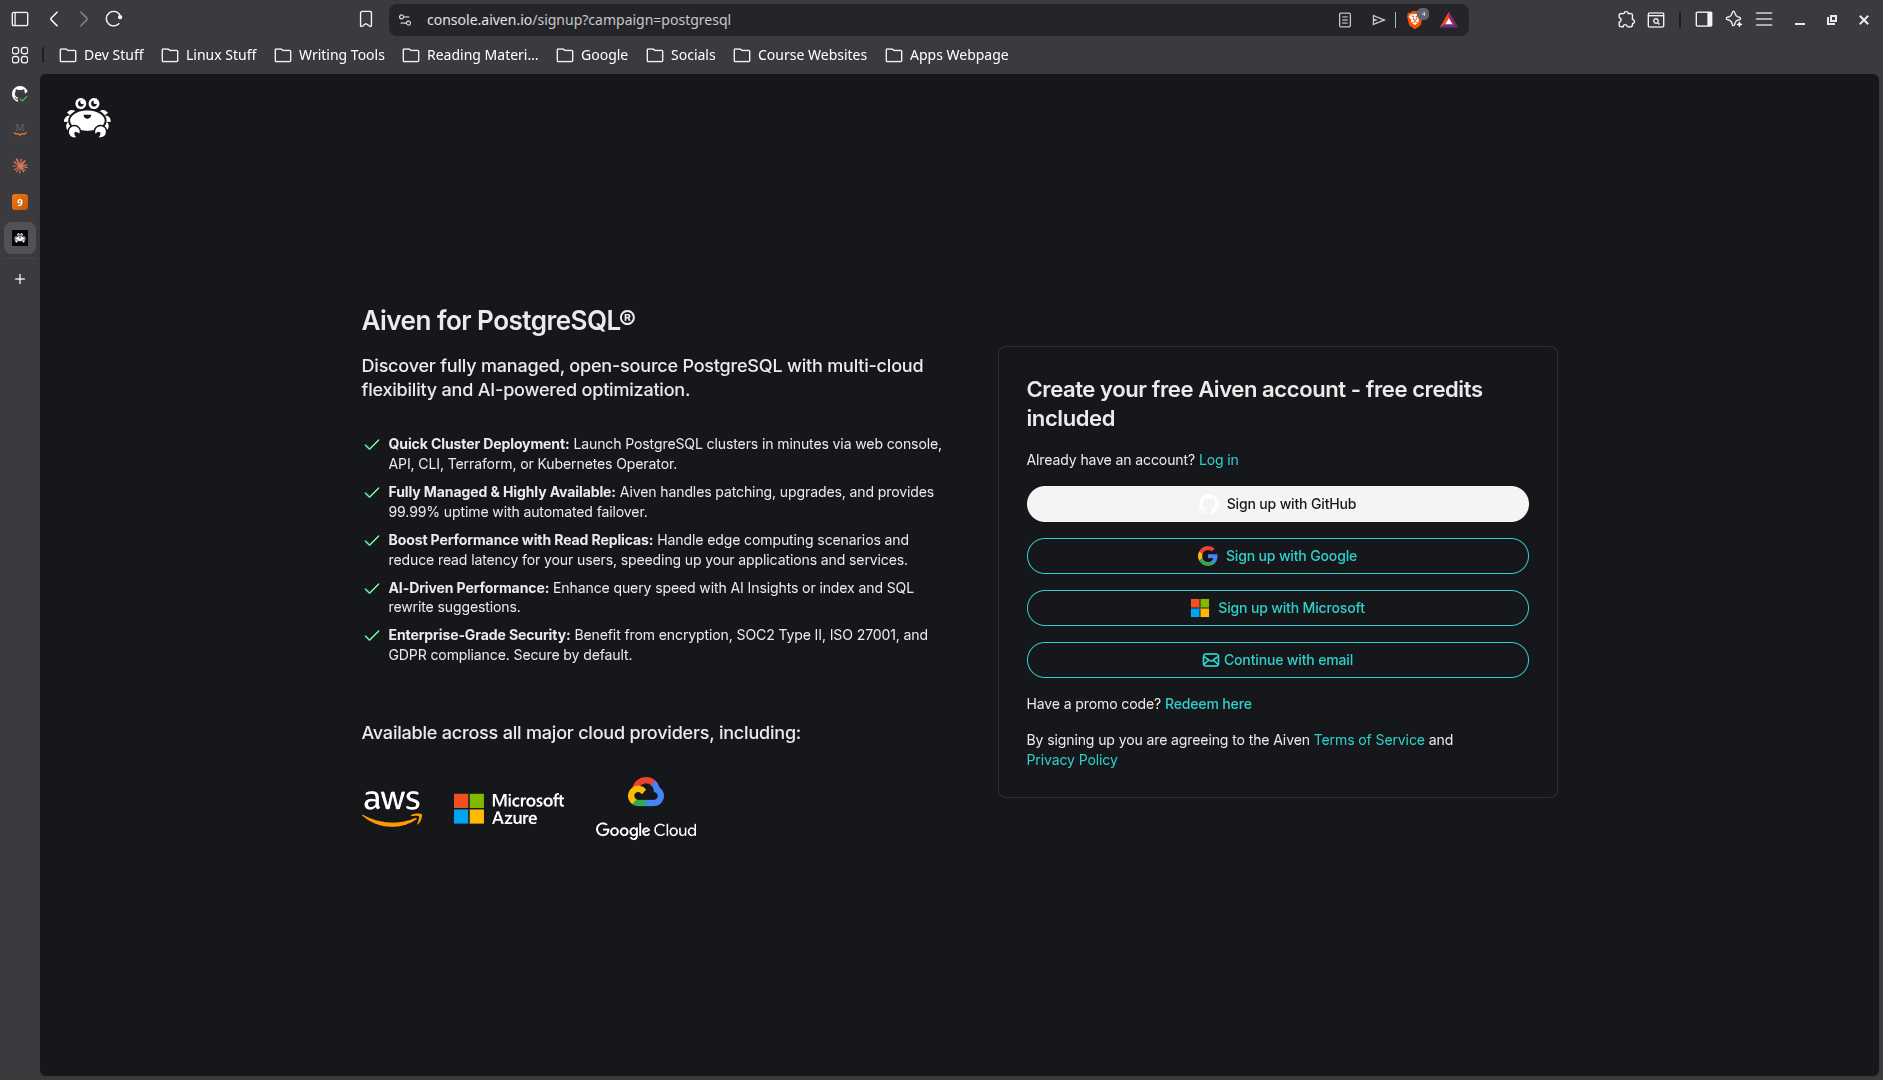

5. **Masuk ke Halaman Layanan (*Services Console*)**  
   Setelah autentikasi berhasil, pastikan Anda berada di dashboard utama pada menu **"Services"**.

   > 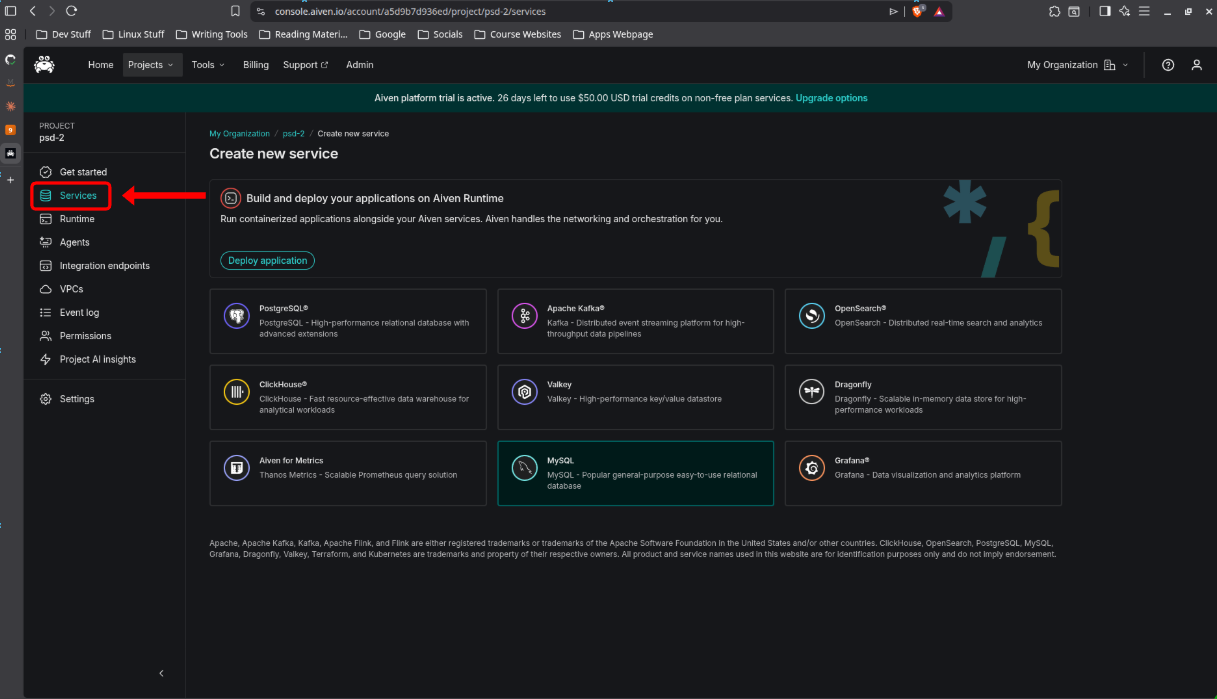

6. **Memilih Tipe Layanan PostgreSQL**  
   Klik tombol **"Create service"** dan pilih kategori basis data **PostgreSQL**.

   > 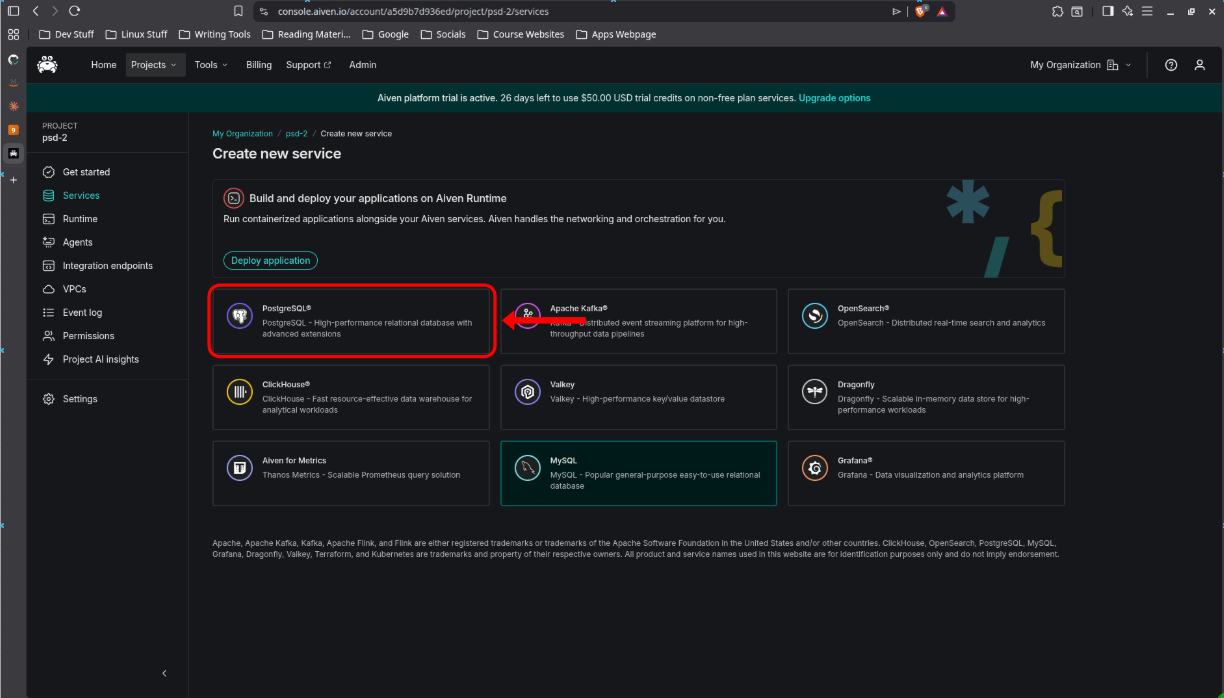

7. **Konfigurasi Spesifikasi dan Lokasi Cloud (*Cloud Provider, Region & Tier*)**  
   Pilih penyedia cloud (misal: AWS / GCP), lokasi data center / region terdekat (misal: Singapore / Jakarta), tipe paket layanan (*service plan/tier*), serta tentukan nama identitas unik untuk layanan database Anda.

   > 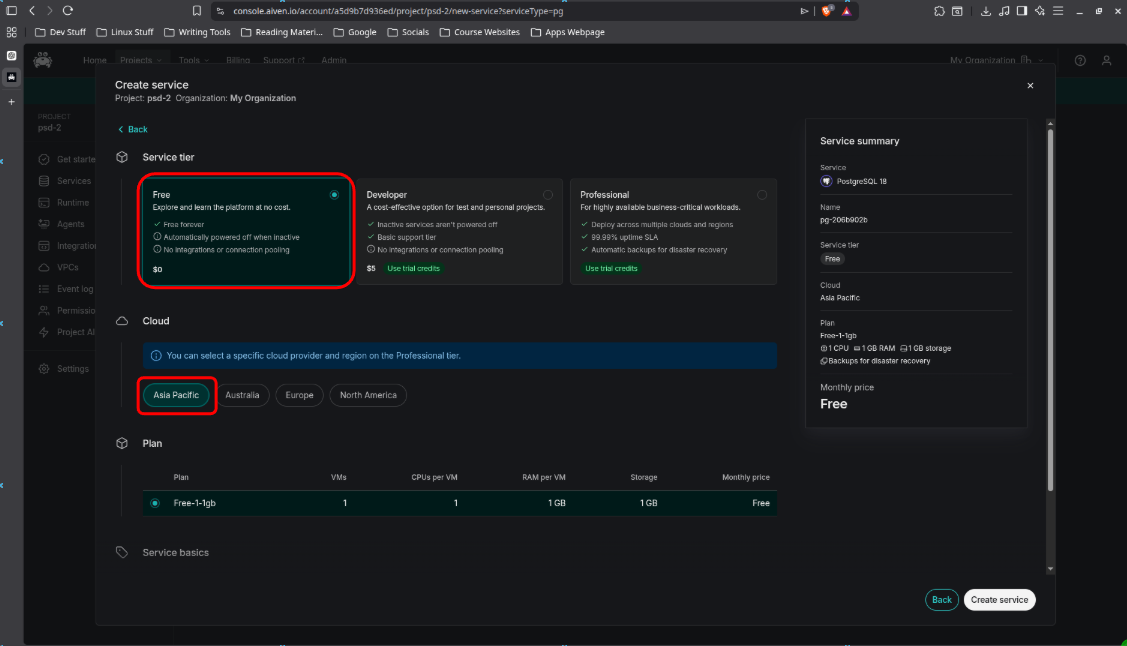

   > 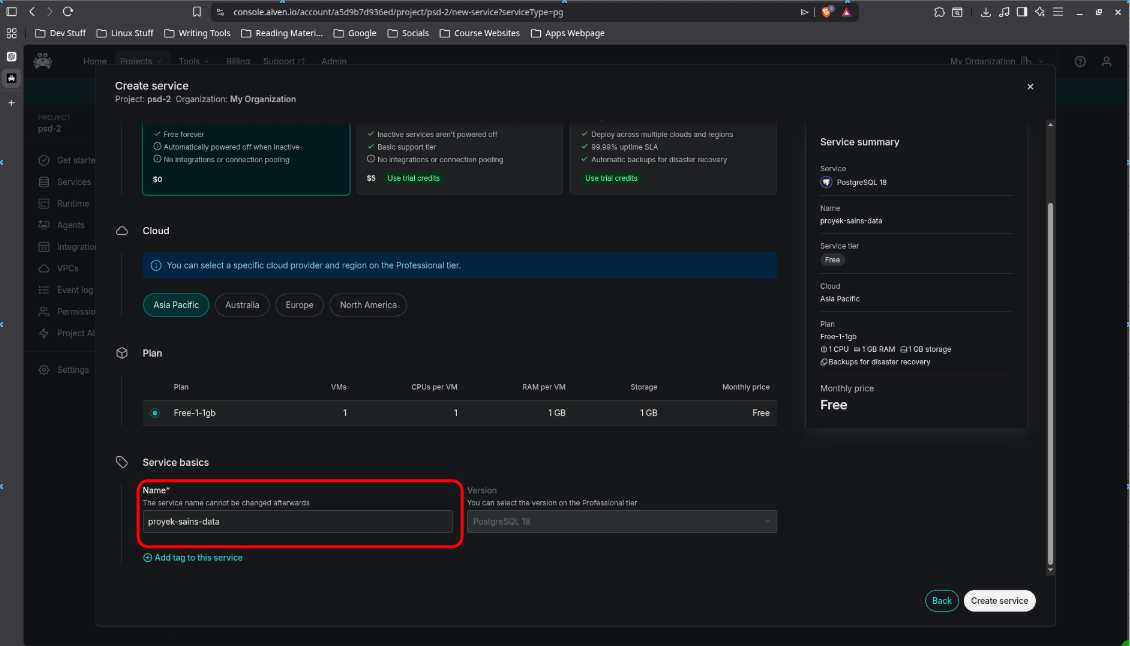

8. **Membuat dan Menjalankan Layanan (*Create Service*)**  
   Periksa kembali rincian konfigurasi, kemudian klik tombol **"Create service"** untuk menginisialisasi instance PostgreSQL di cloud.

   > 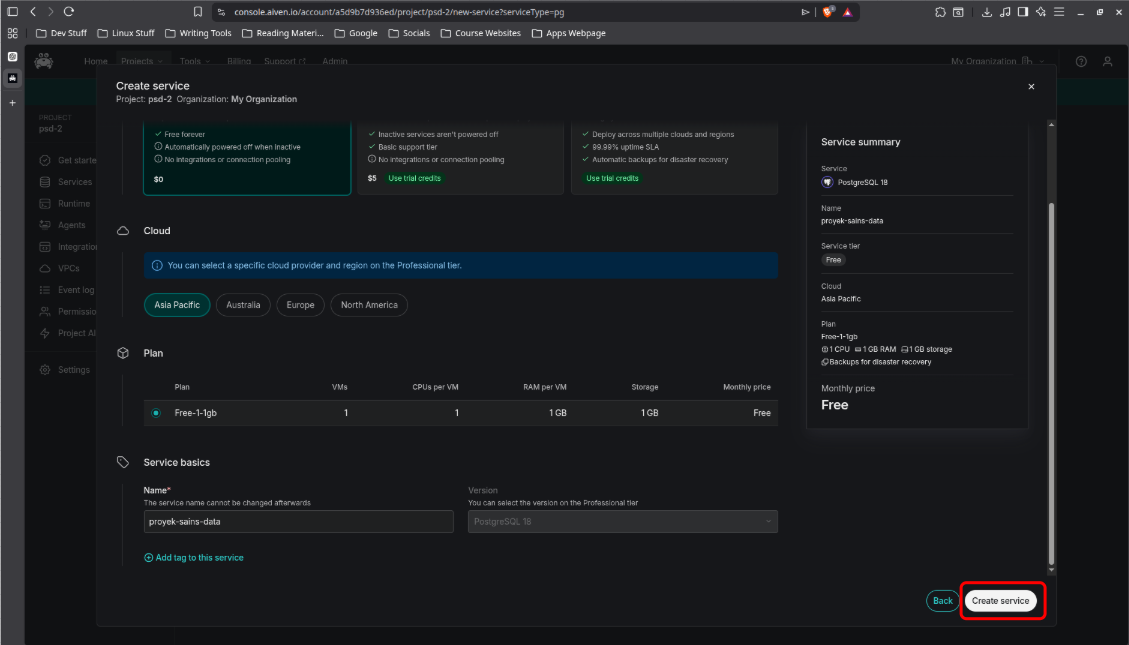

9. **Melihat Ringkasan Kredensial dan Informasi Layanan**  
   Setelah instance aktif (*status: Running*), sistem Aiven akan menampilkan informasi lengkap koneksi seperti *Host*, *Port*, *User*, *Password*, dan *Database Name* (URI koneksi).

   > 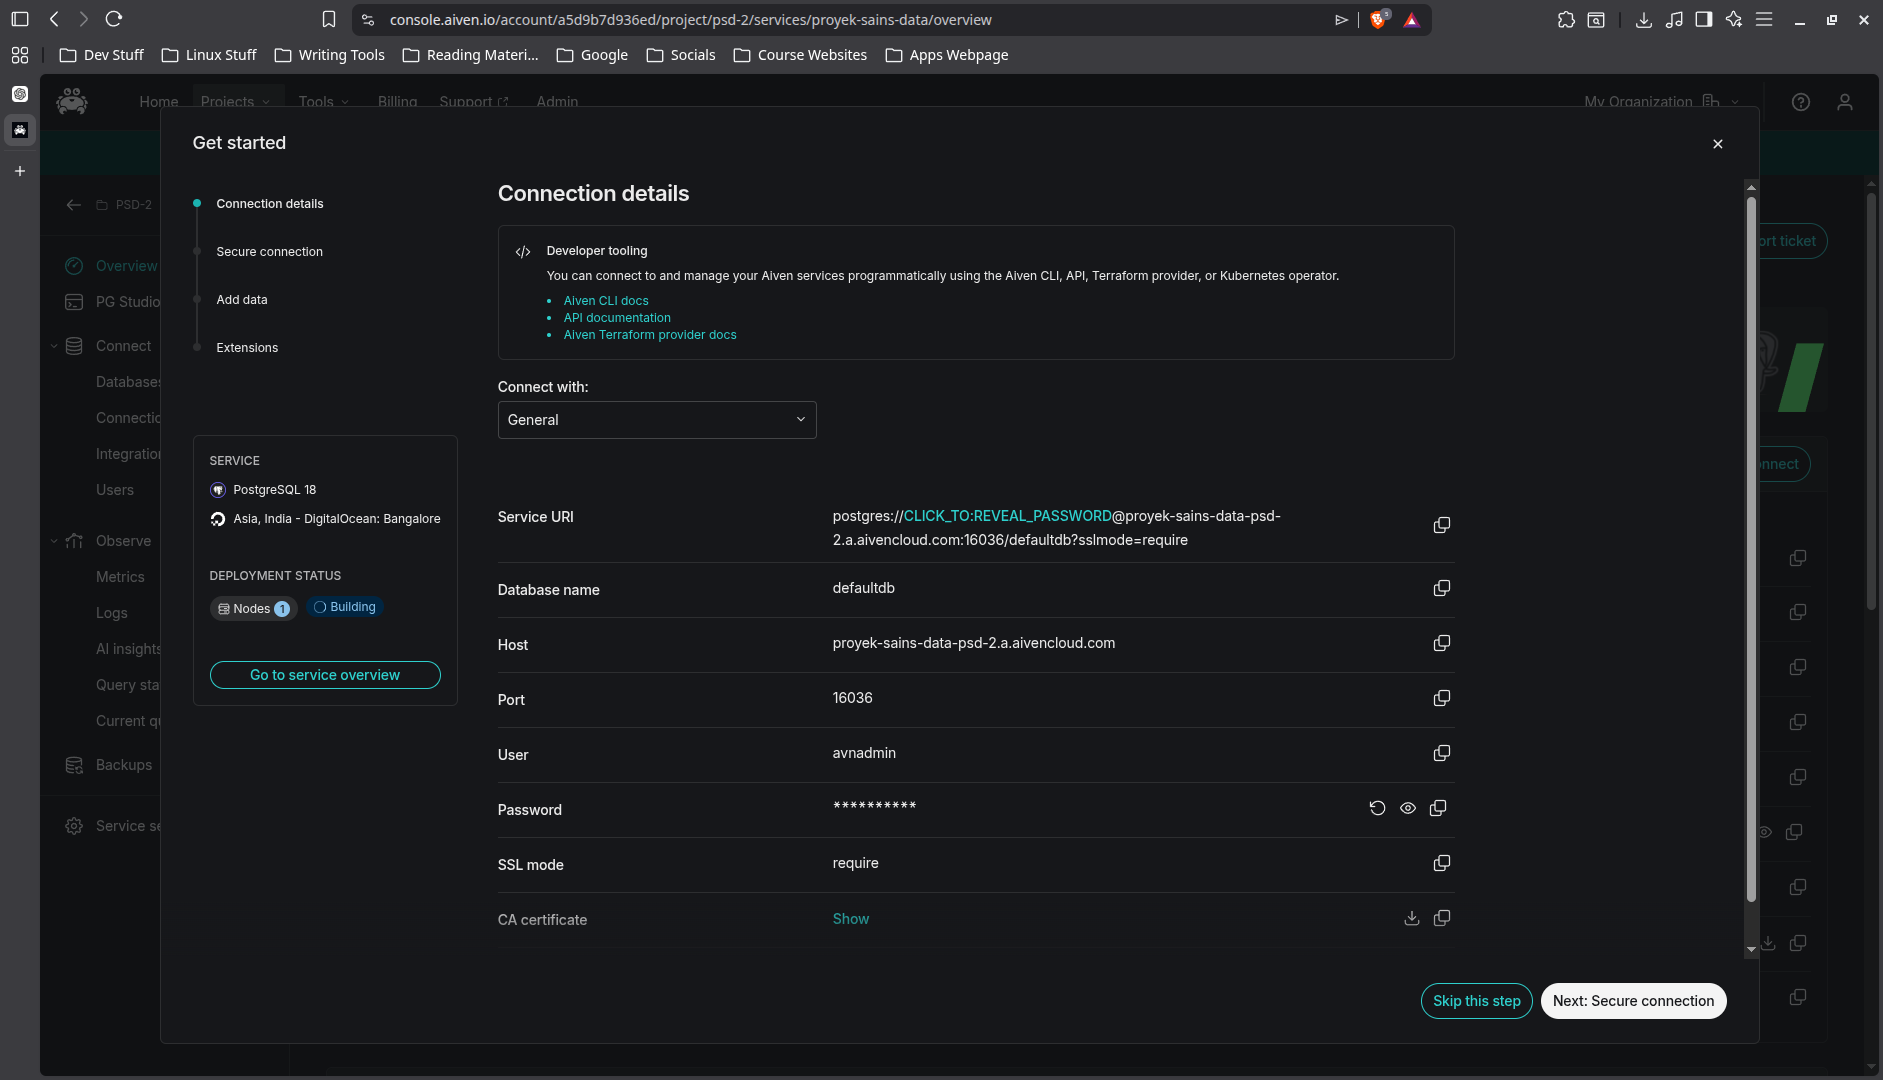

10. **Melewati Panduan Awal (*Skip Onboarding*)**  
    Klik **"Skip this step"** atau **"Done"** untuk menyelesaikan proses setup awal pada web console Aiven.

    > 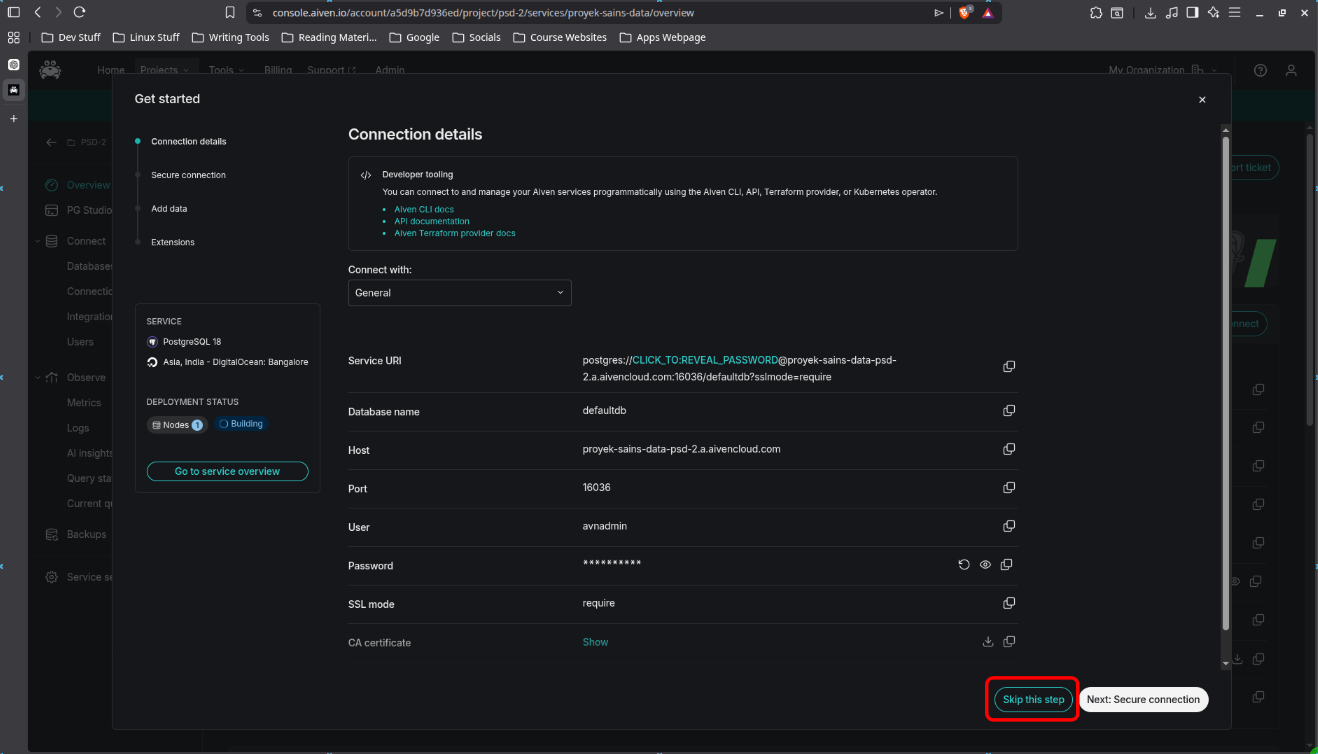

---

### 2. Menyambungkan Layanan Database Aiven dengan DBeaver

1. **Membuka Aplikasi DBeaver**  
   Jalankan aplikasi Database Manager **DBeaver** pada komputer lokal Anda.

   > 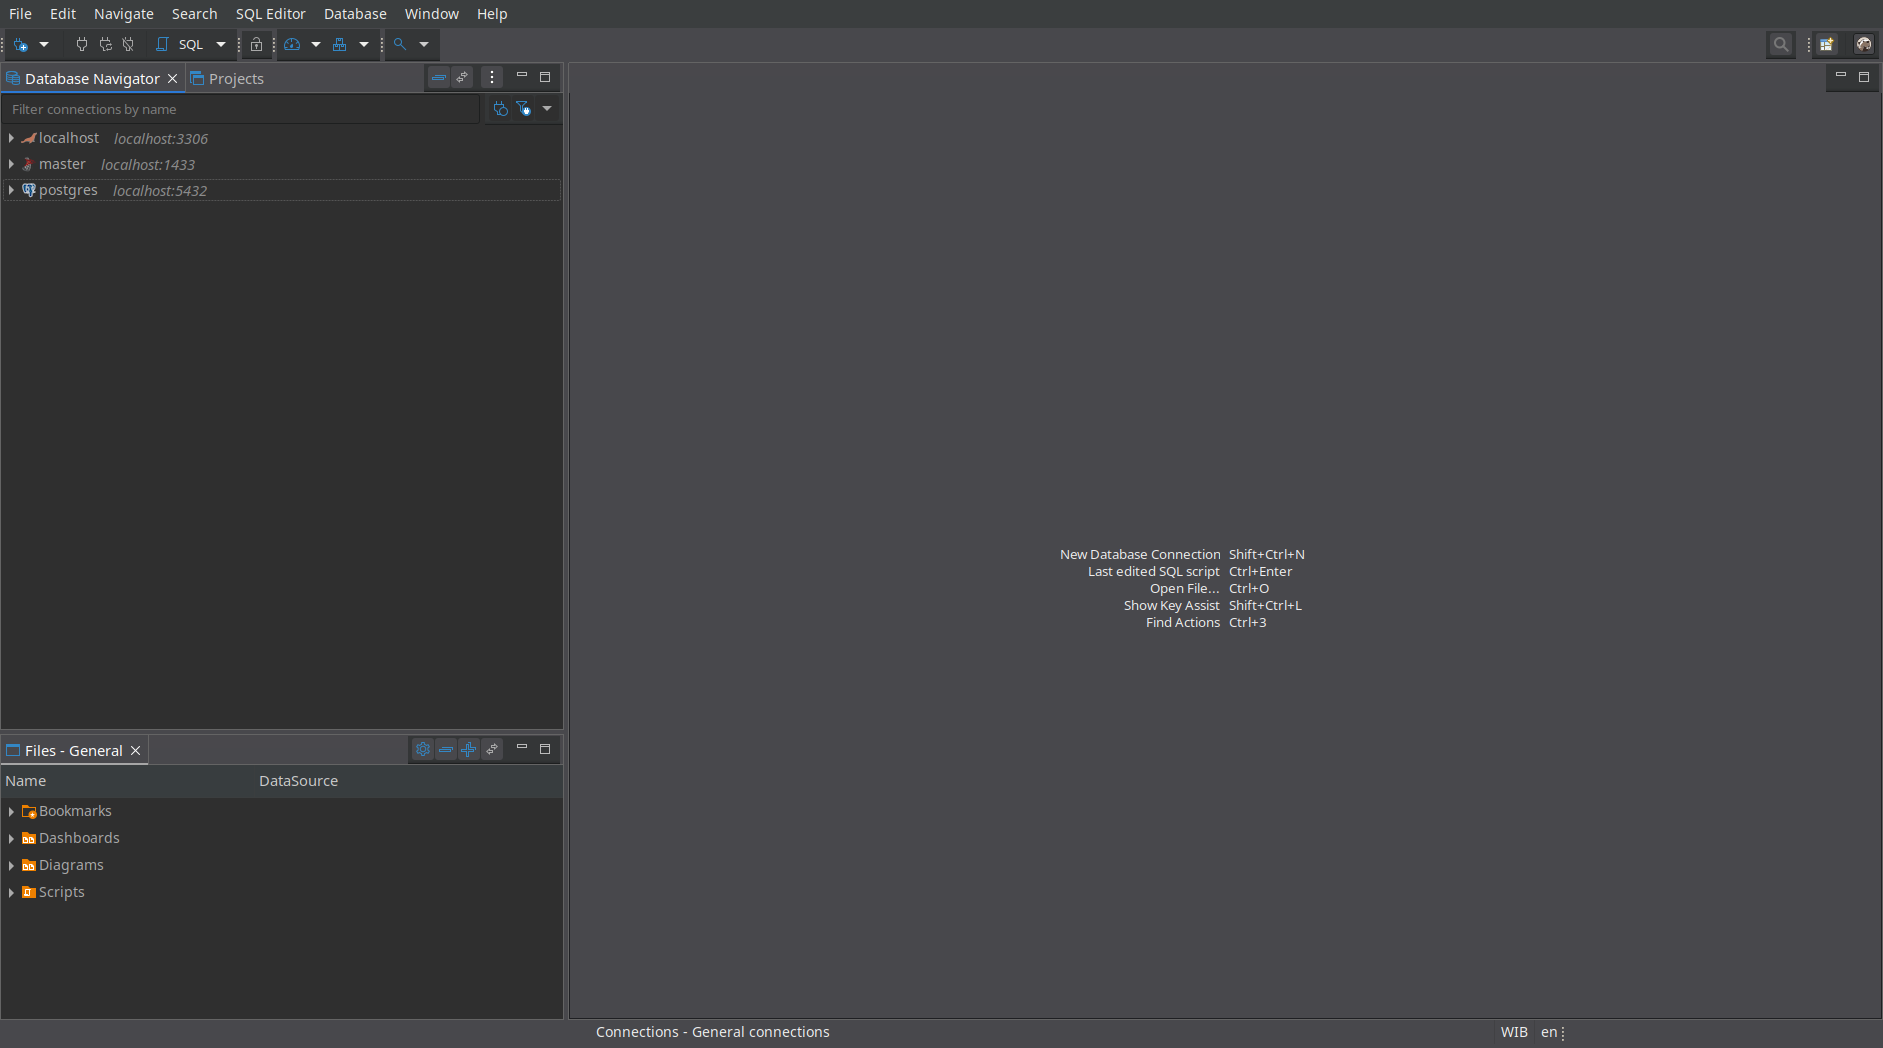

2. **Membuat Koneksi Basis Data Baru (*New Database Connection*)**  
   Pilih jenis database **PostgreSQL**, kemudian salin dan tempelkan parameter koneksi dari Aiven (*Host*, *Port*, *Database name*, *Username*, dan *Password*). Lakukan uji koneksi (*Test Connection*), lalu klik **"Finish"**.

   > 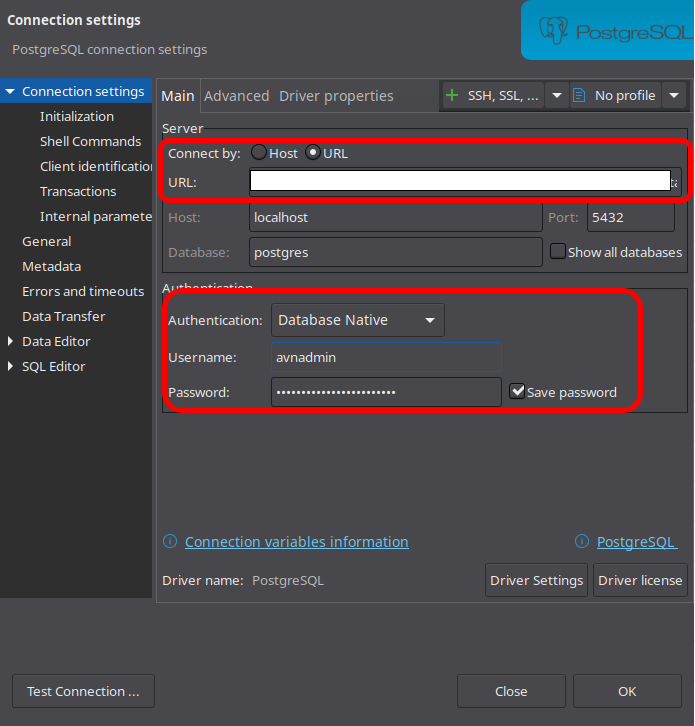

3. **Koneksi Database Berhasil Terhubung**  
   Instance PostgreSQL Aiven kini telah berhasil tersambung dan siap dikelola langsung melalui antarmuka DBeaver.

   > 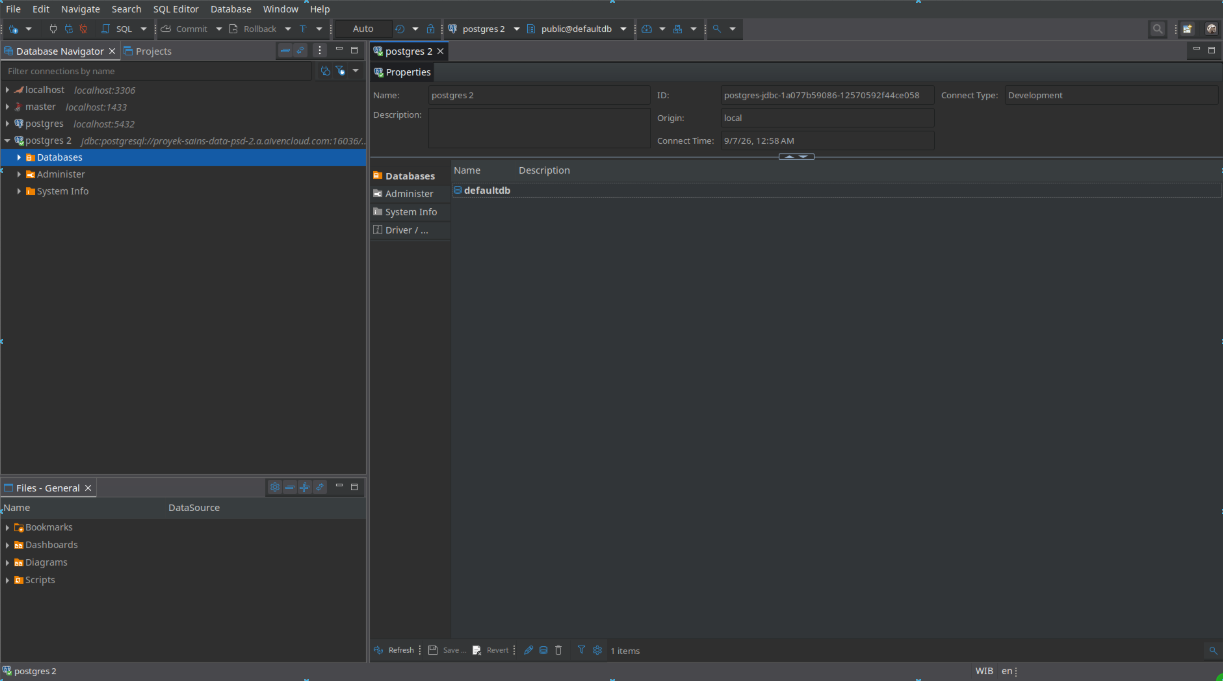

---

### 3. Mengimpor Data Kualitas Udara (CSV) ke Database

1. **Membuka Skema Database pada DBeaver**  
   Navigasikan panel Database Navigator ke `Service Aiven > Databases > defaultdb > Schemas > public > Tables`.

   > 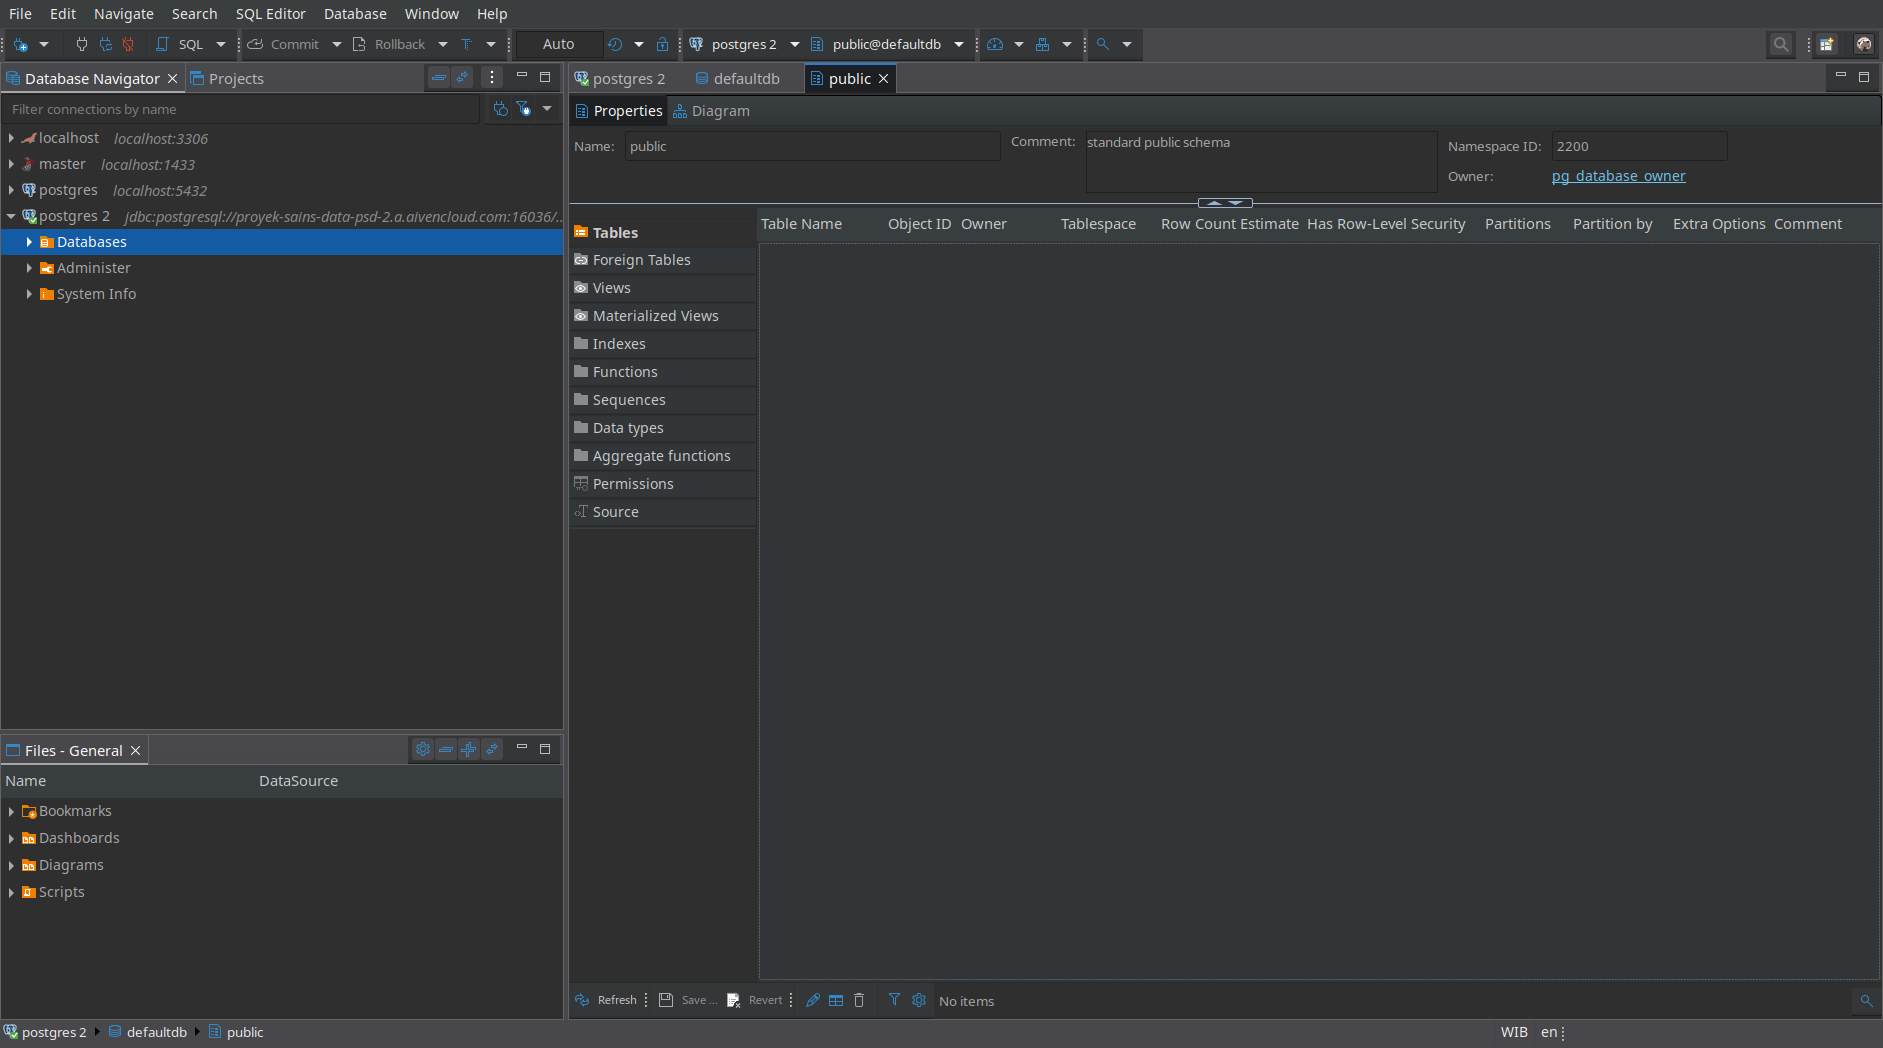

2. **Memilih Menu Impor Data (*Import Data*)**  
   Klik kanan pada menu folder **Tables** atau tabel target, lalu pilih opsi **"Import Data"**.

   > 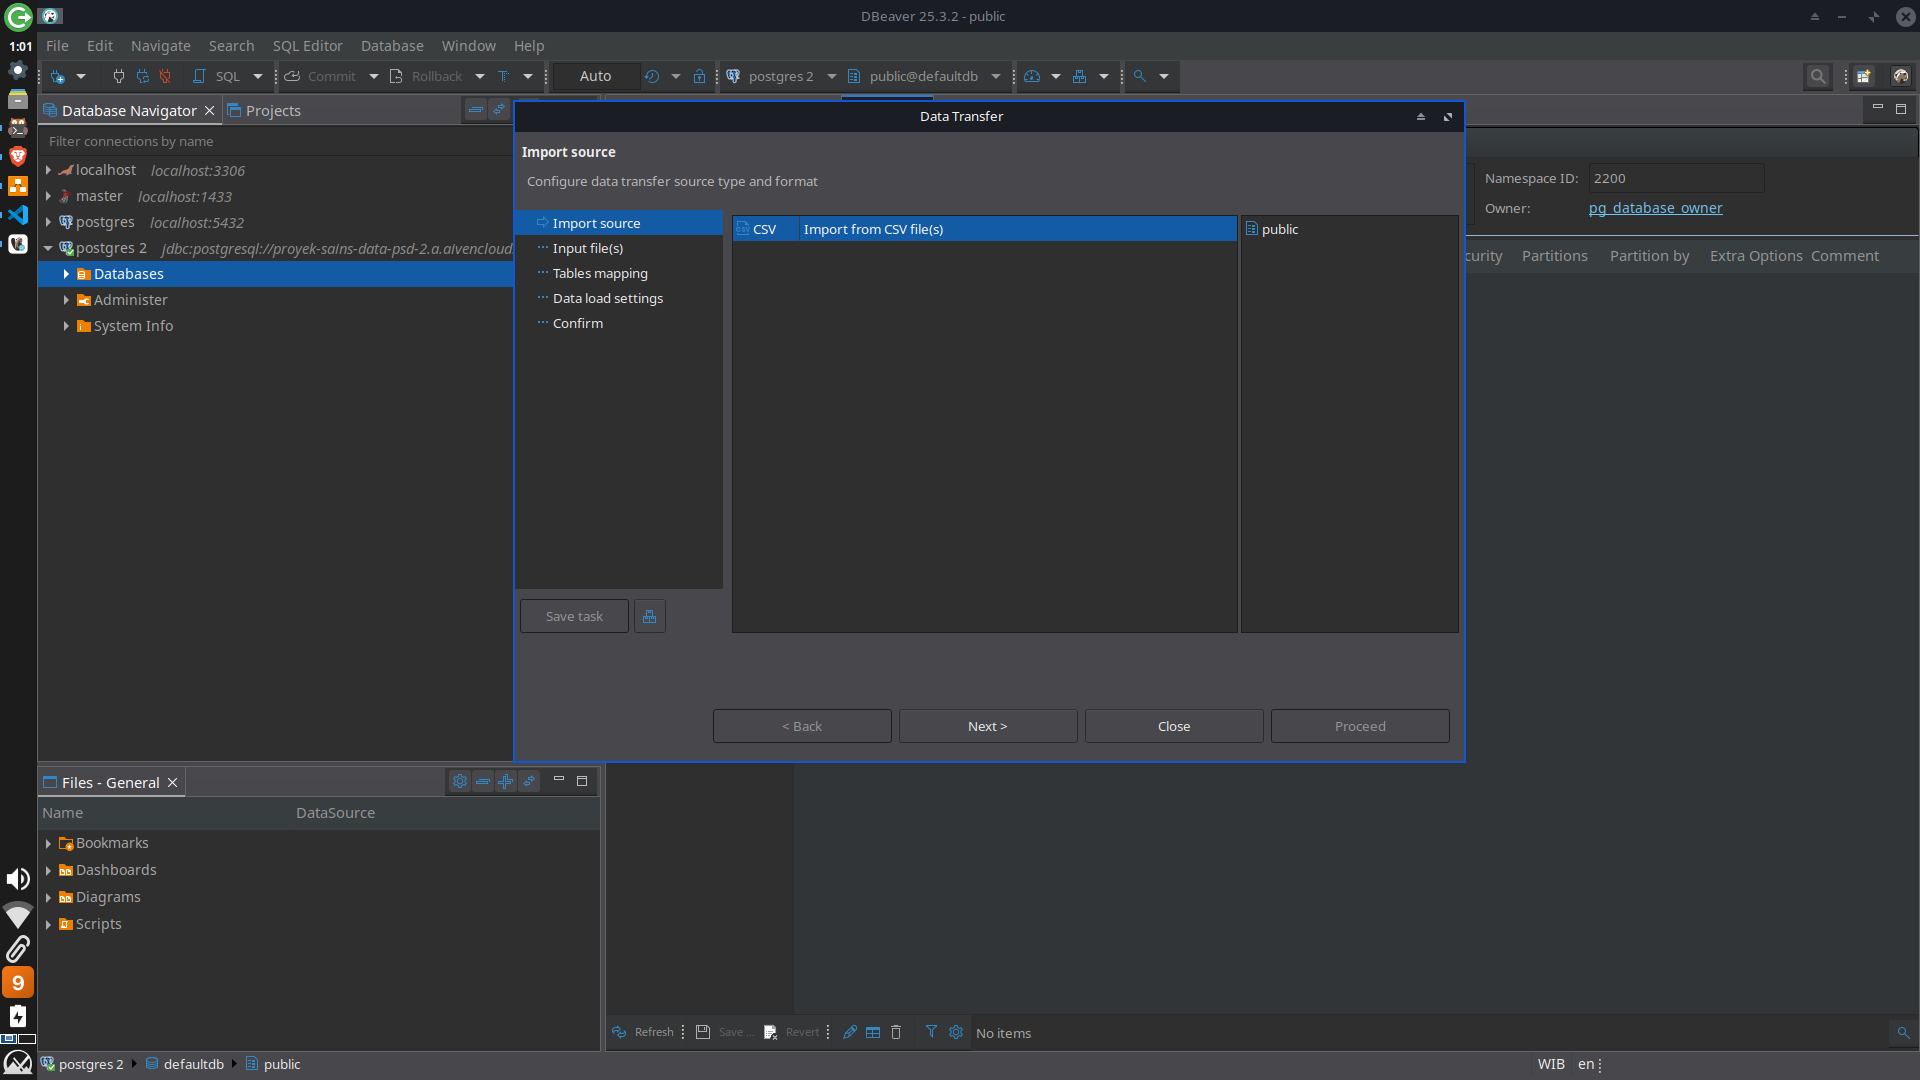

3. **Memilih Format Sumber Data (CSV)**  
   Pada jendela wizard impor, pilih format **CSV** sebagai tipe berkas sumber data, kemudian klik **"Next"**.

   > 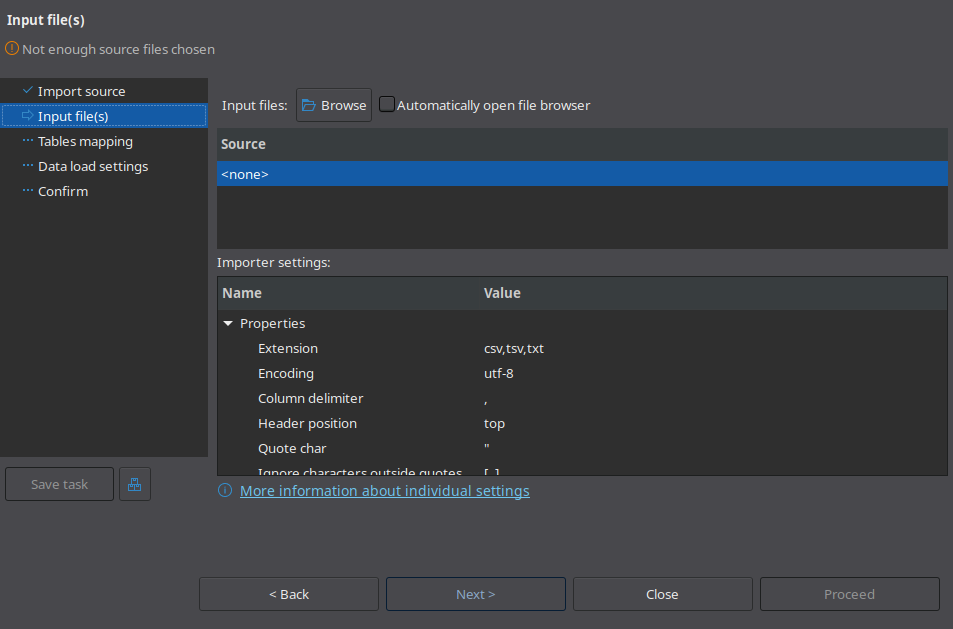

4. **Memilih Berkas CSV Hasil Tugas 1**  
   Klik tombol **"Browse"** dan arahkan ke lokasi penyimpanan berkas `data_kualitas_udara.csv` yang telah disiapkan dari pengerjaan Tugas 1.

   > 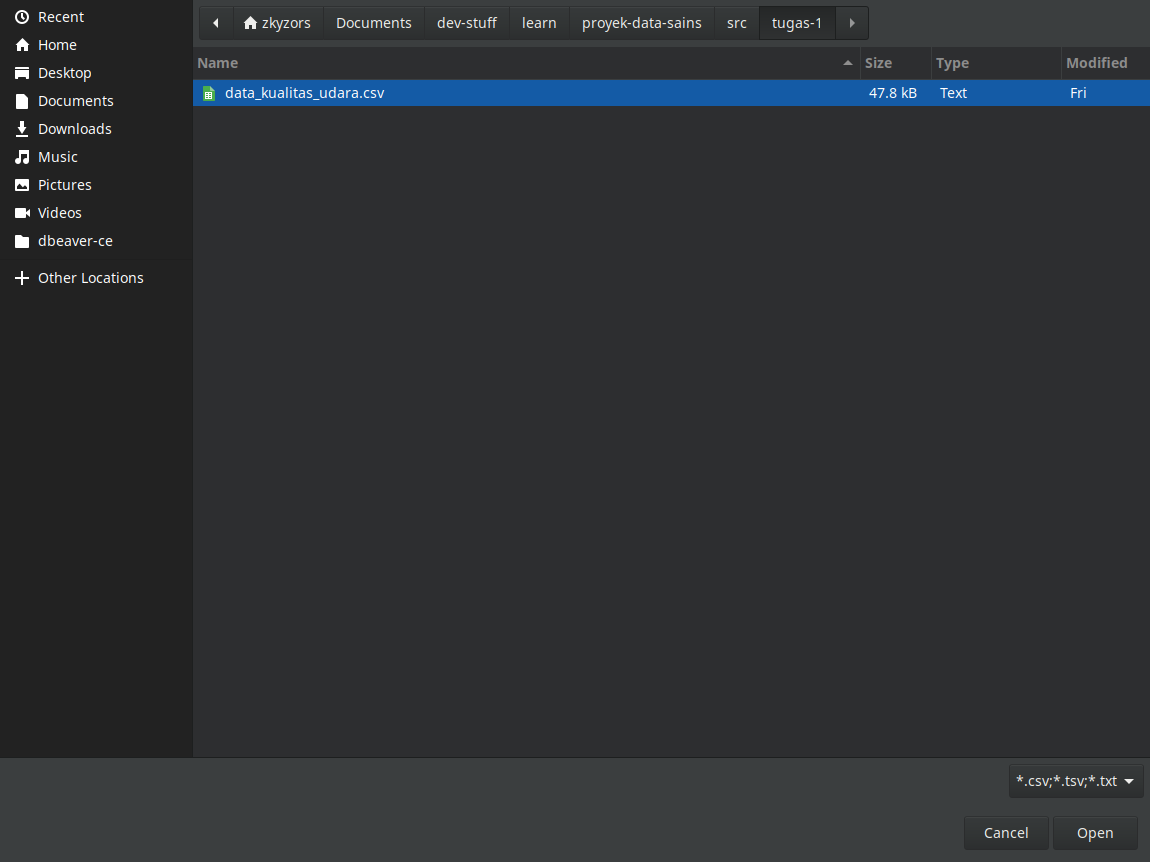

5. **Membuka Berkas (*Open File*)**  
   Pilih berkas `data_kualitas_udara.csv` dan klik tombol **"Open"**.

   > 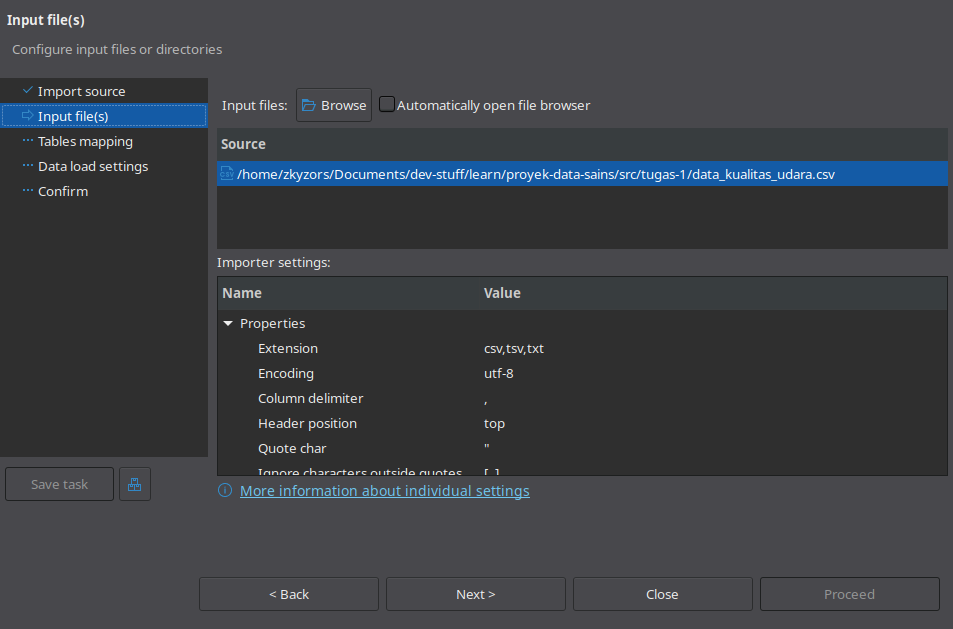

6. **Konfigurasi Parameter Input File**  
   Periksa pembatas kolom (*delimiter comma* `,`) dan encoding file pada halaman *Input File*, lalu klik **"Next"**.

   > 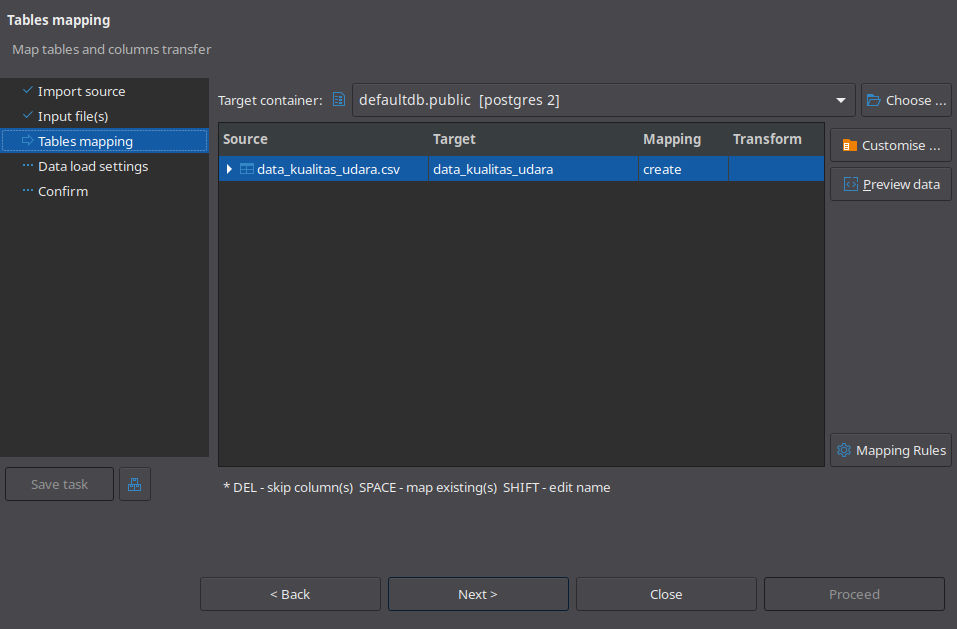

7. **Pemetaan Kolom Tabel (*Tables Mapping*)**  
   Pastikan struktur kolom dataset (`date`, `CO`, `HCHO`, `NO2`, `O3`, `SO2`, `CH4`) telah terpetakan dengan tepat ke tipe data kolom target pada tabel database, kemudian klik **"Next"**.

   > 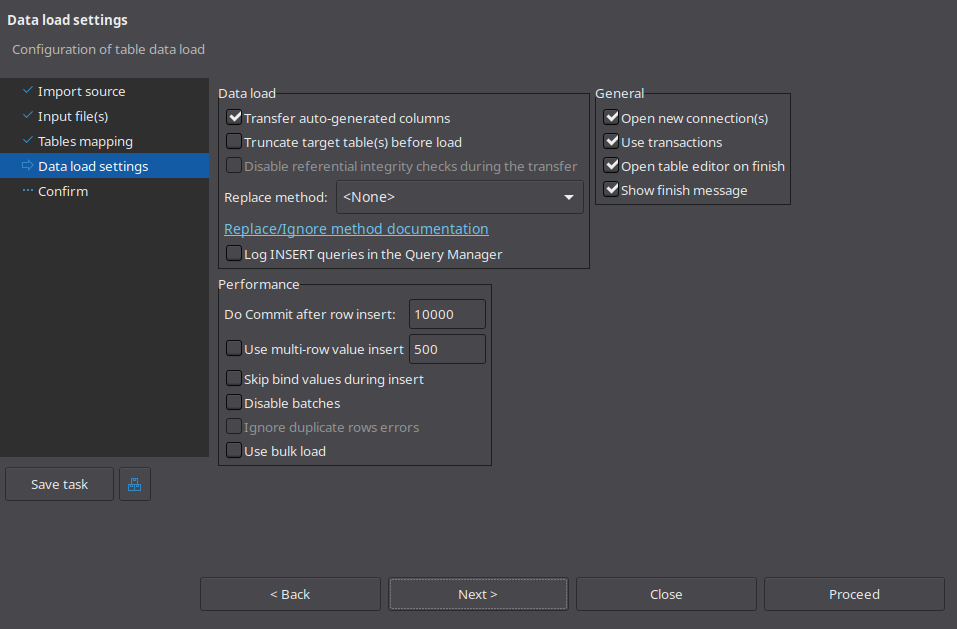

8. **Pengaturan Pemuatan Data (*Data Load Settings*) & Eksekusi**  
   Pada halaman pengaturan akhir pemuatan data, klik tombol **"Proceed"** untuk memulai proses transfer data ke database cloud Aiven.

   > 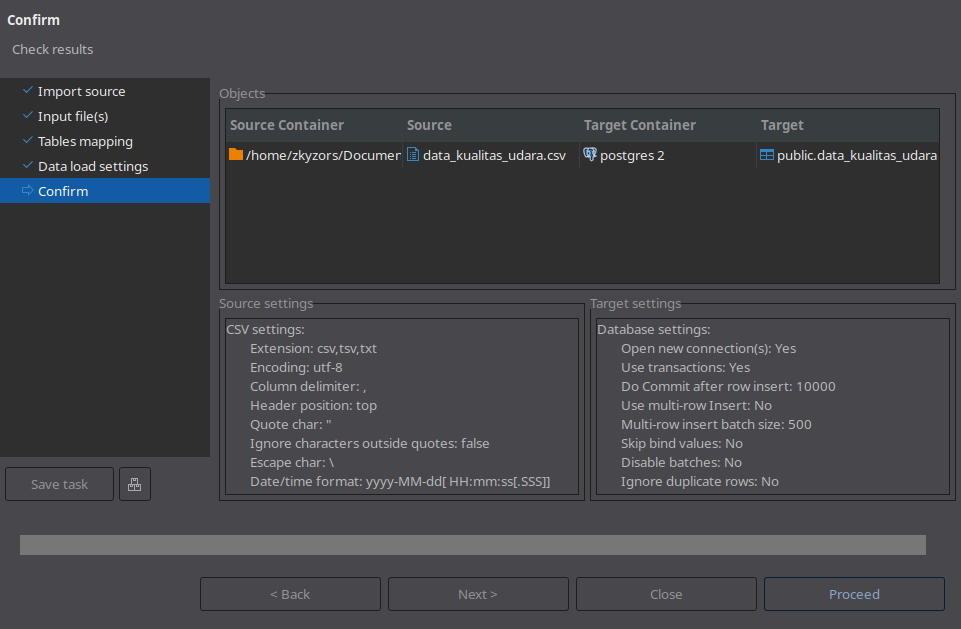

9. **Verifikasi Keberhasilan Impor Data**  
   Proses impor telah selesai. Seluruh baris data kualitas udara dari berkas CSV telah tersimpan secara permanen dan terstruktur rapi di dalam tabel database PostgreSQL di Aiven.

   > 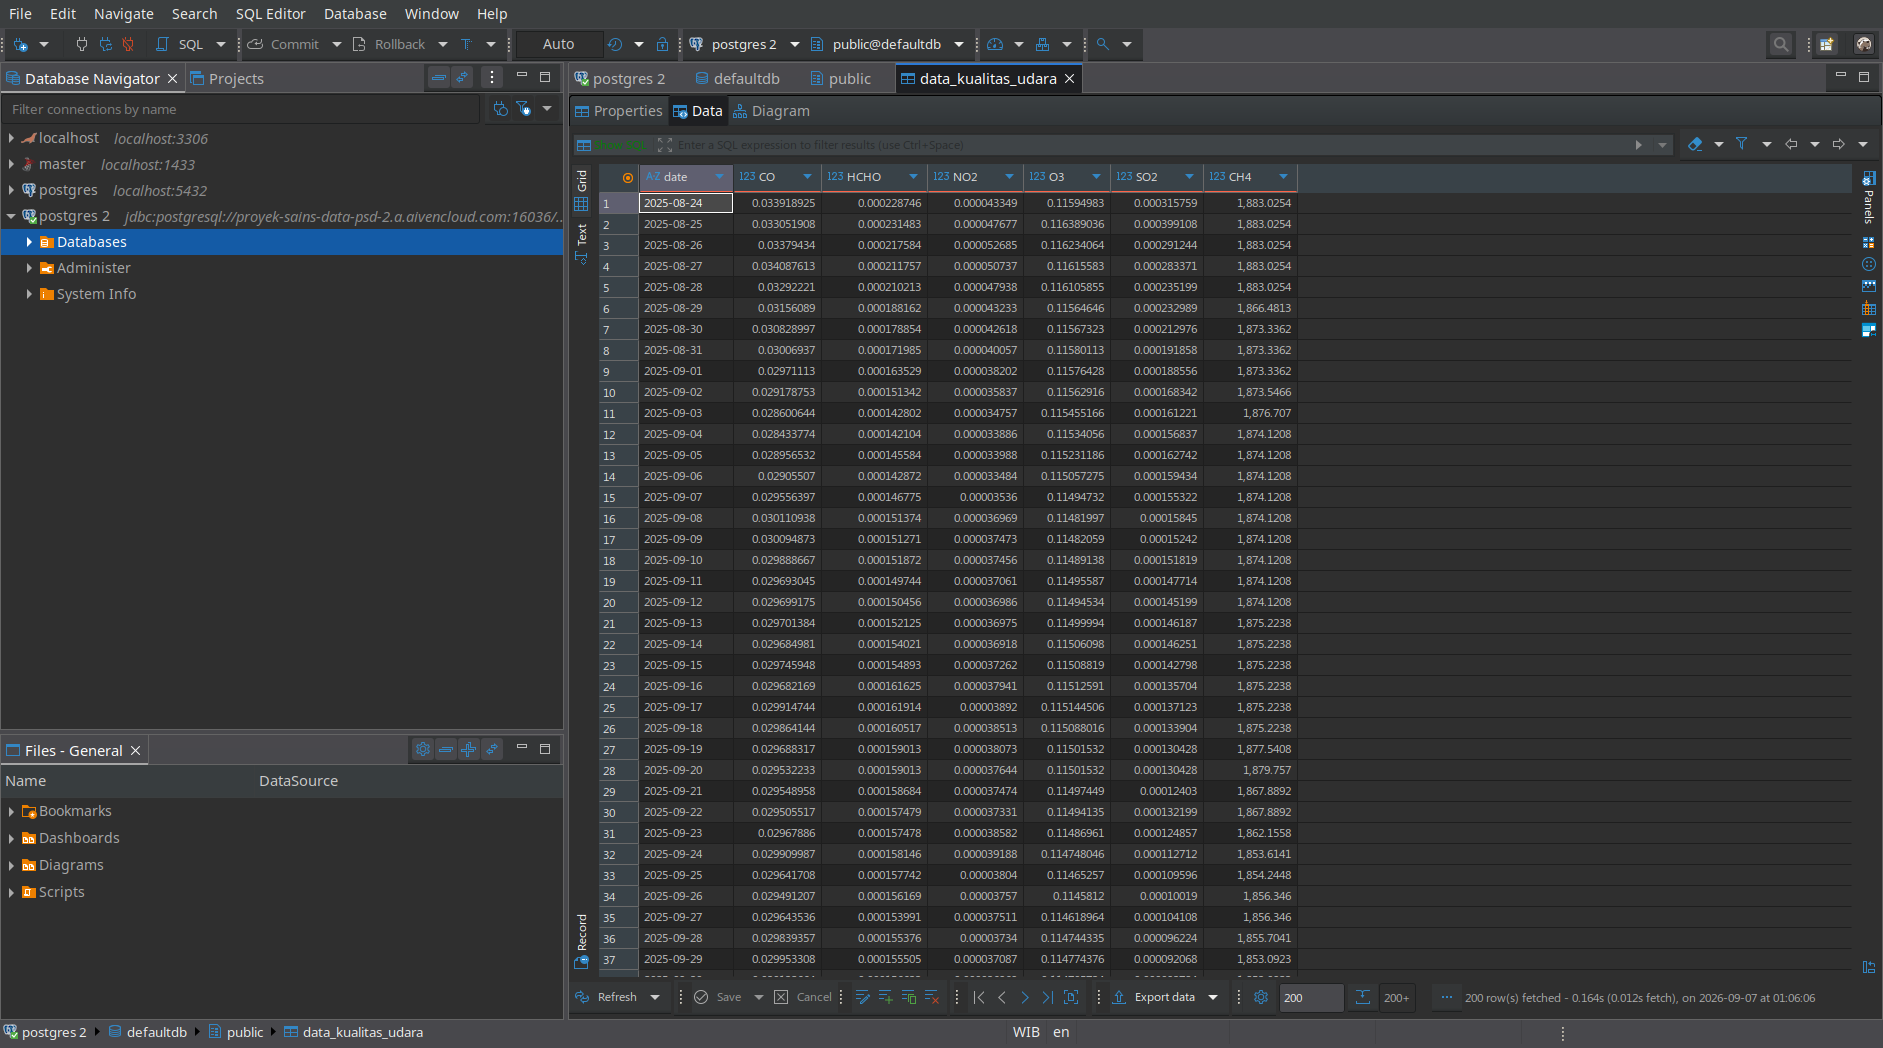


## Proses Menampilkan Statistika Data Kualitas Udara (Via KNIME)

Setelah data kualitas udara berhasil dimigrasikan ke database cloud PostgreSQL di Aiven, langkah berikutnya adalah menghubungkan KNIME Analytics Platform dengan database tersebut untuk membaca dataset dan melakukan *data profiling* statistik secara otomatis.


### 1. Pembuatan Workflow Baru di KNIME Analytics Platform

1. **Membuka Aplikasi KNIME**  
   Jalankan software **KNIME Analytics Platform** di komputer lokal hingga masuk ke tampilan beranda (*Welcome Screen / KNIME Explorer*).

   > 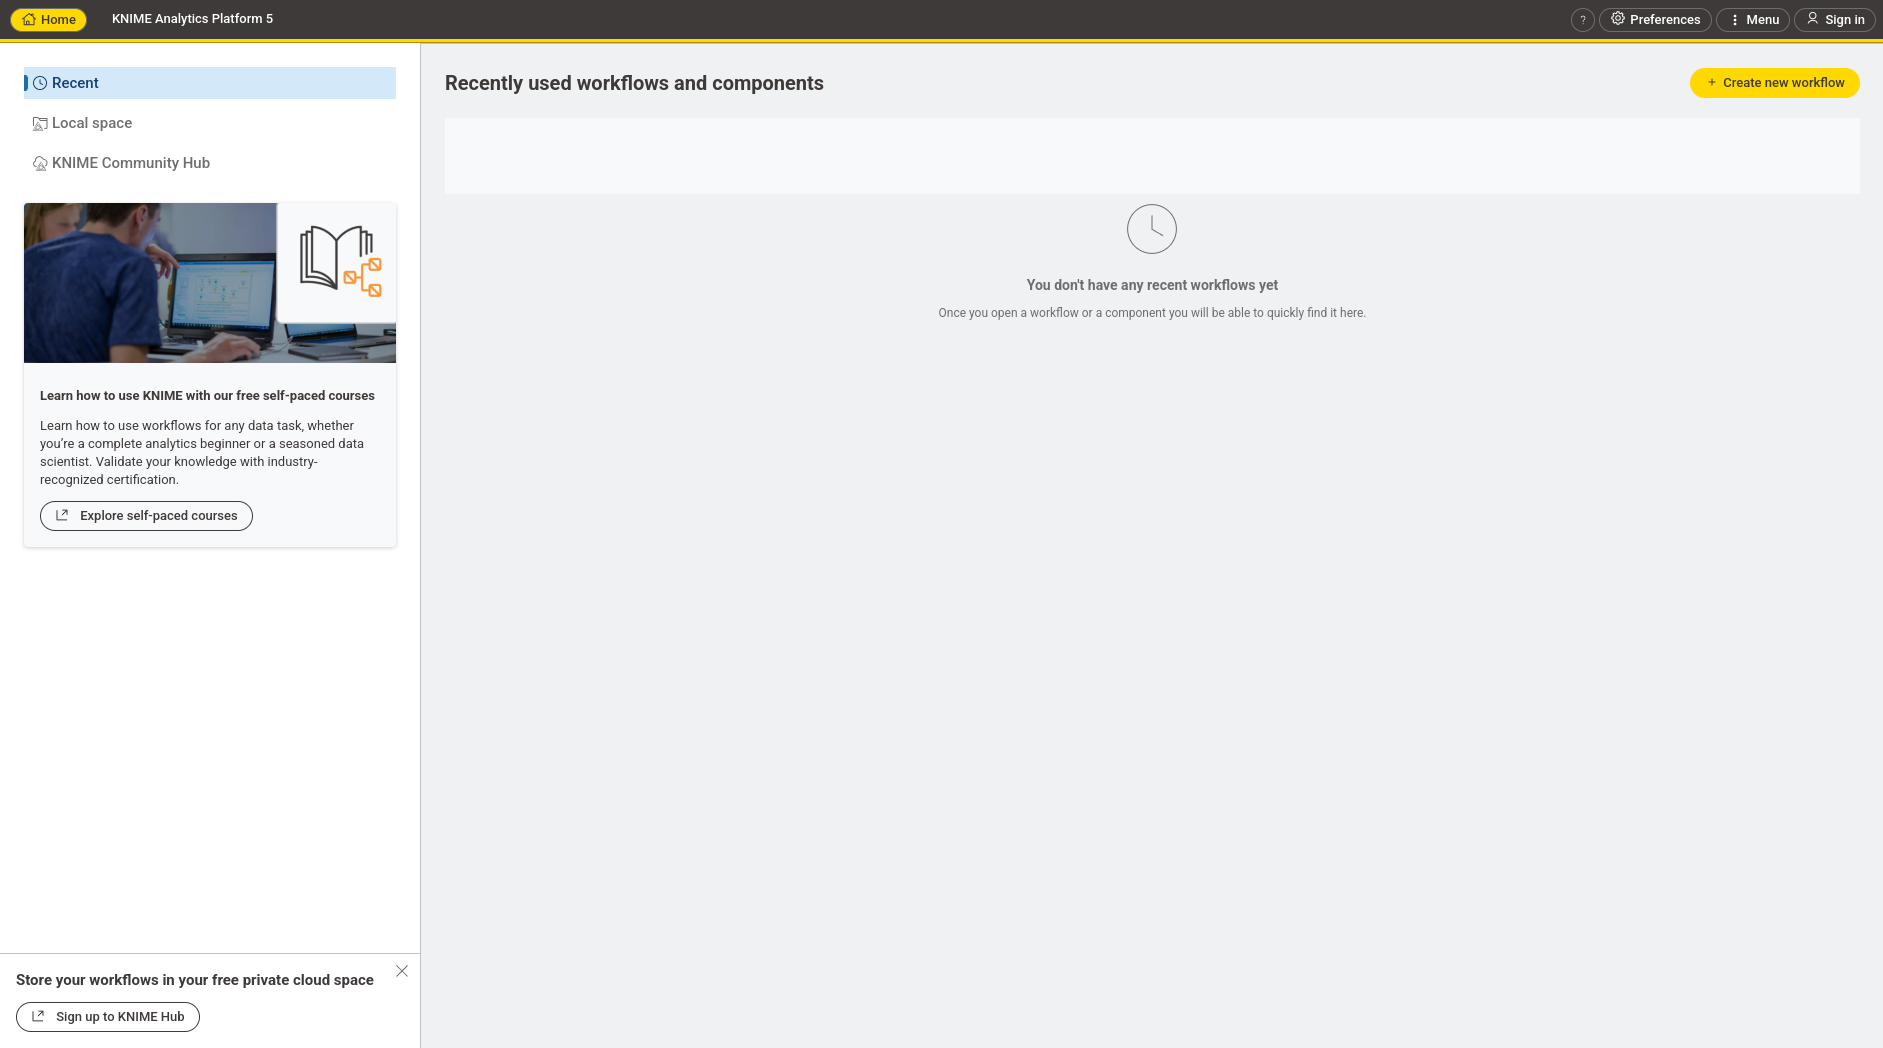

2. **Membuat Proyek Workflow Baru (*New Workflow*)**  
   Klik tombol **"Create new workflow"** atau melalui menu file untuk membuka lembar kerja kosong baru.

   > 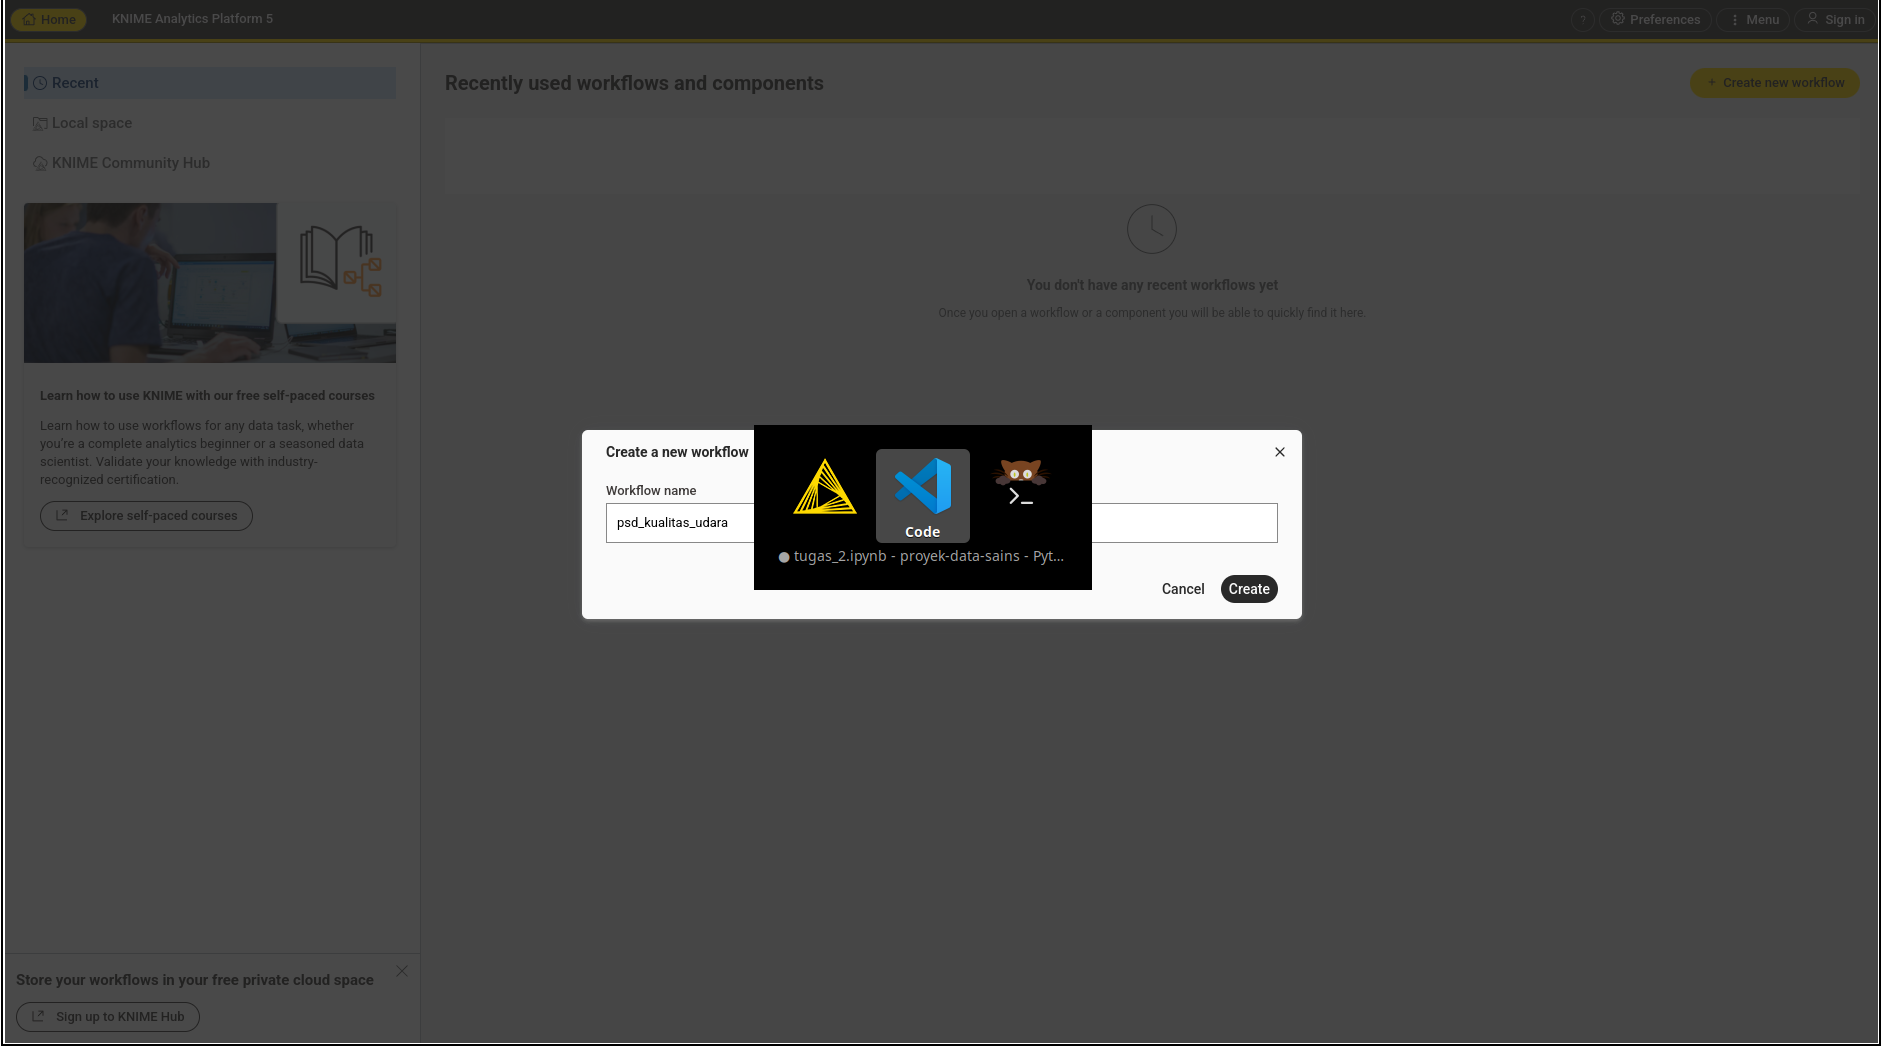

3. **Lembar Kerja (*Workflow Canvas*) Siap Digunakan**  
   Setelah workflow baru berhasil dibuat, kanvas visual siap digunakan untuk menyusun alur node pemrosesan data.

   > 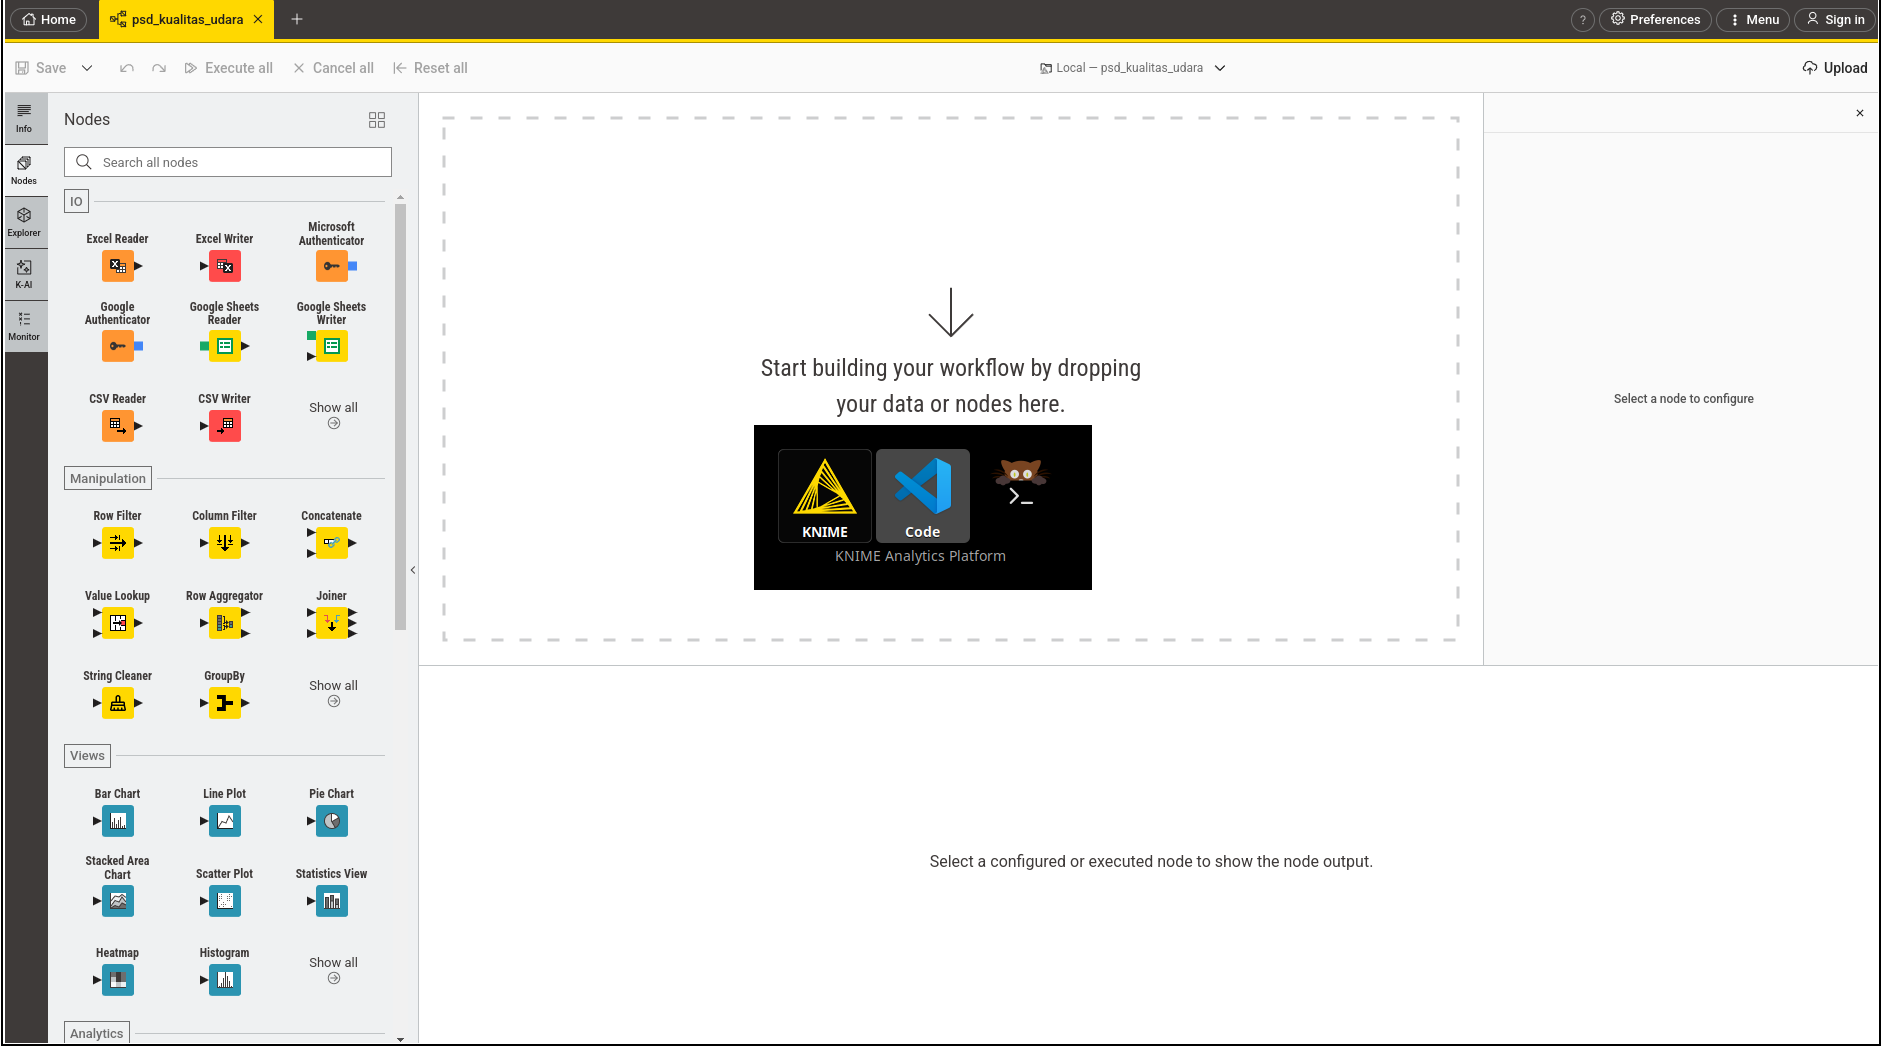


### 2. Menyambungkan Database Cloud Aiven ke KNIME

1. **Menambahkan Node *PostgreSQL Connector***  
   Cari node **"PostgreSQL Connector"** pada panel *Node Repository*, kemudian *drag-and-drop* node tersebut ke dalam kanvas workflow.

   > 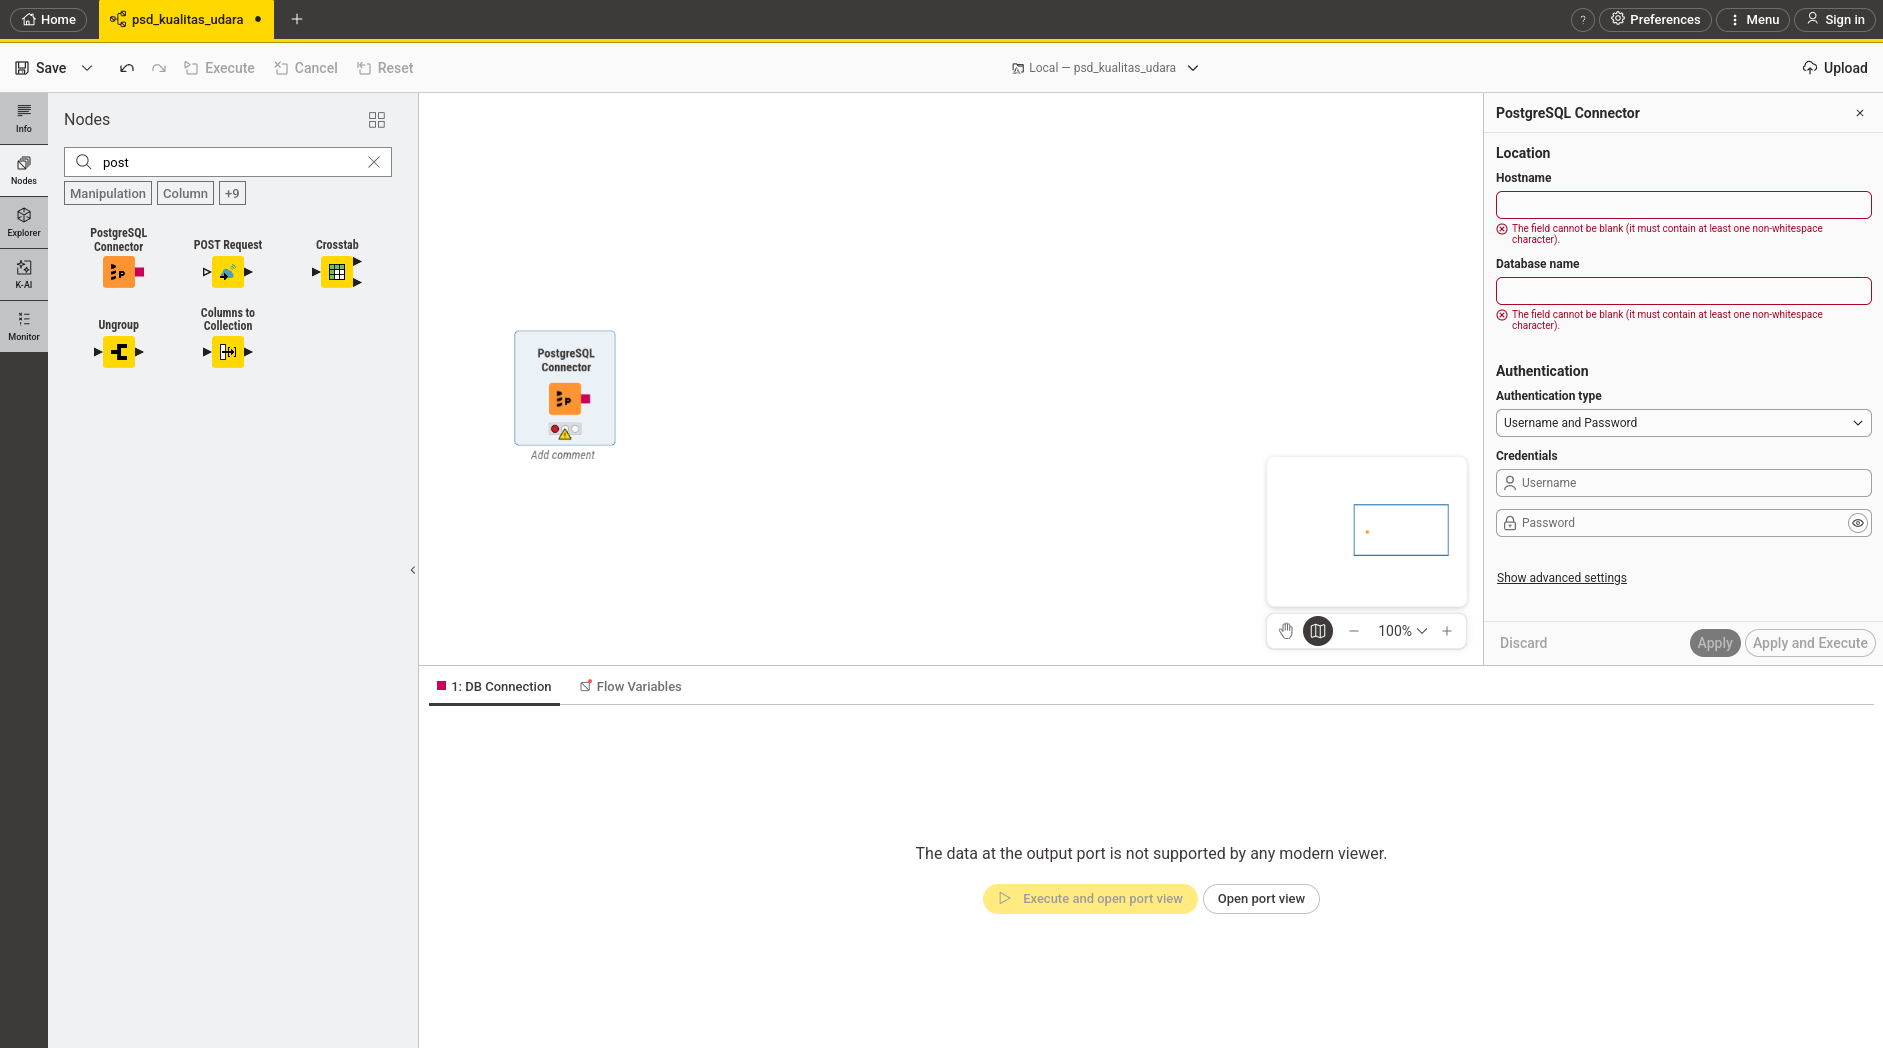

2. **Konfigurasi Kredensial Database Cloud**  
   Buka konfigurasi node *PostgreSQL Connector* dan masukkan rincian koneksi Aiven (*Host*, *Port*, *Database name*, *Username*, dan *Password*). Klik tombol **"Apply and Execute"** untuk menghubungkan KNIME ke server PostgreSQL Aiven.

   > 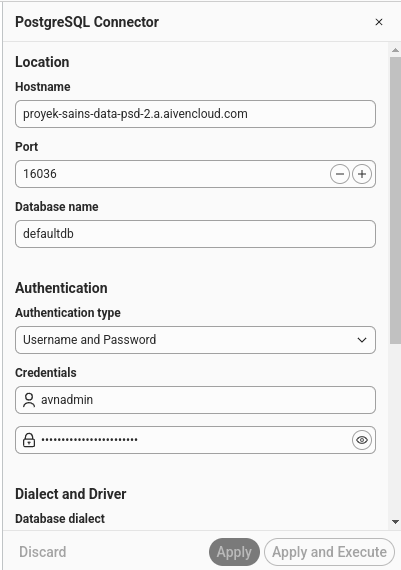


### 3. Memilih Tabel Data Kualitas Udara (*DB Table Selector*)

1. **Menambahkan Node *DB Table Selector***  
   Tarik node **"DB Table Selector"** ke kanvas dan hubungkan port input database-nya dengan port output dari node *PostgreSQL Connector*.

   > 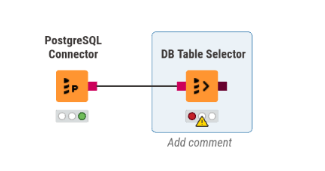

2. **Membuka Penelusuran Skema Tabel (*Browse Table*)**  
   Buka panel konfigurasi pada sidebar kanan, lalu klik tombol **"Browse"** untuk melihat daftar skema dan tabel yang tersedia di database.

   > 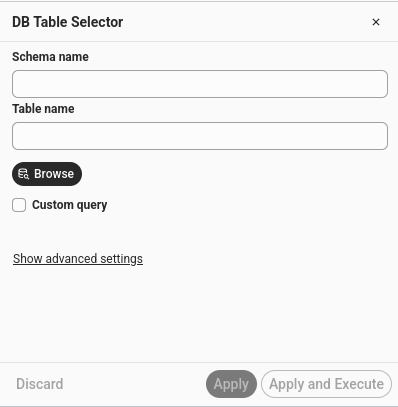

3. **Memilih Skema dan Tabel Target**  
   Pilih skema `public` dan tentukan tabel data kualitas udara yang telah diimpor sebelumnya (`data_kualitas_udara`).

   > 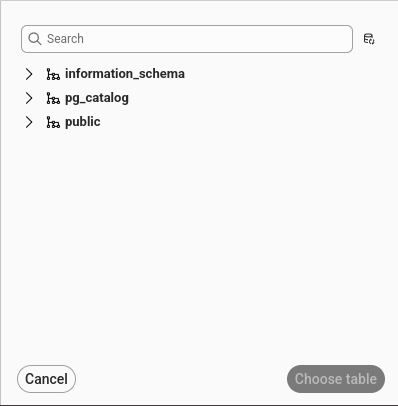

4. **Mengonfirmasi Pemilihan Tabel (*Choose Table*)**  
   Pastikan tabel yang dipilih sudah sesuai, kemudian klik tombol **"Choose Table"**.

   > 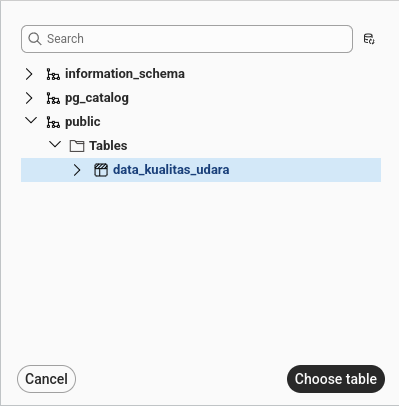

5. **Mengeksekusi Konfigurasi Tabel**  
   Klik tombol **"Apply and Execute"** untuk menyimpan query referensi tabel pada sesi database.

   > 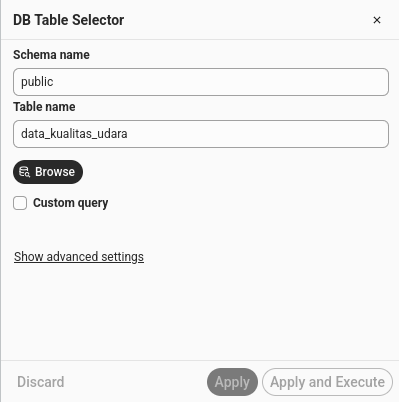


### 4. Membaca Data dan Menampilkan Profil Statistik (*DB Reader*)

1. **Menambahkan dan Menghubungkan Node *DB Reader***  
   Tarik node **"DB Reader"** ke kanvas dan sambungkan port input-nya dari port output node *DB Table Selector* untuk mengambil data aktual dari server database cloud ke dalam memori kerja KNIME.

   > 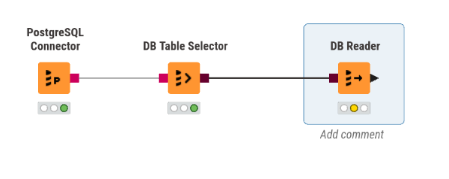

2. **Mengeksekusi Node *DB Reader***  
   Klik kanan atau tekan tombol *Execute* pada node *DB Reader* hingga lampu indikator status berubah menjadi warna hijau (berhasil dieksekusi).

   > 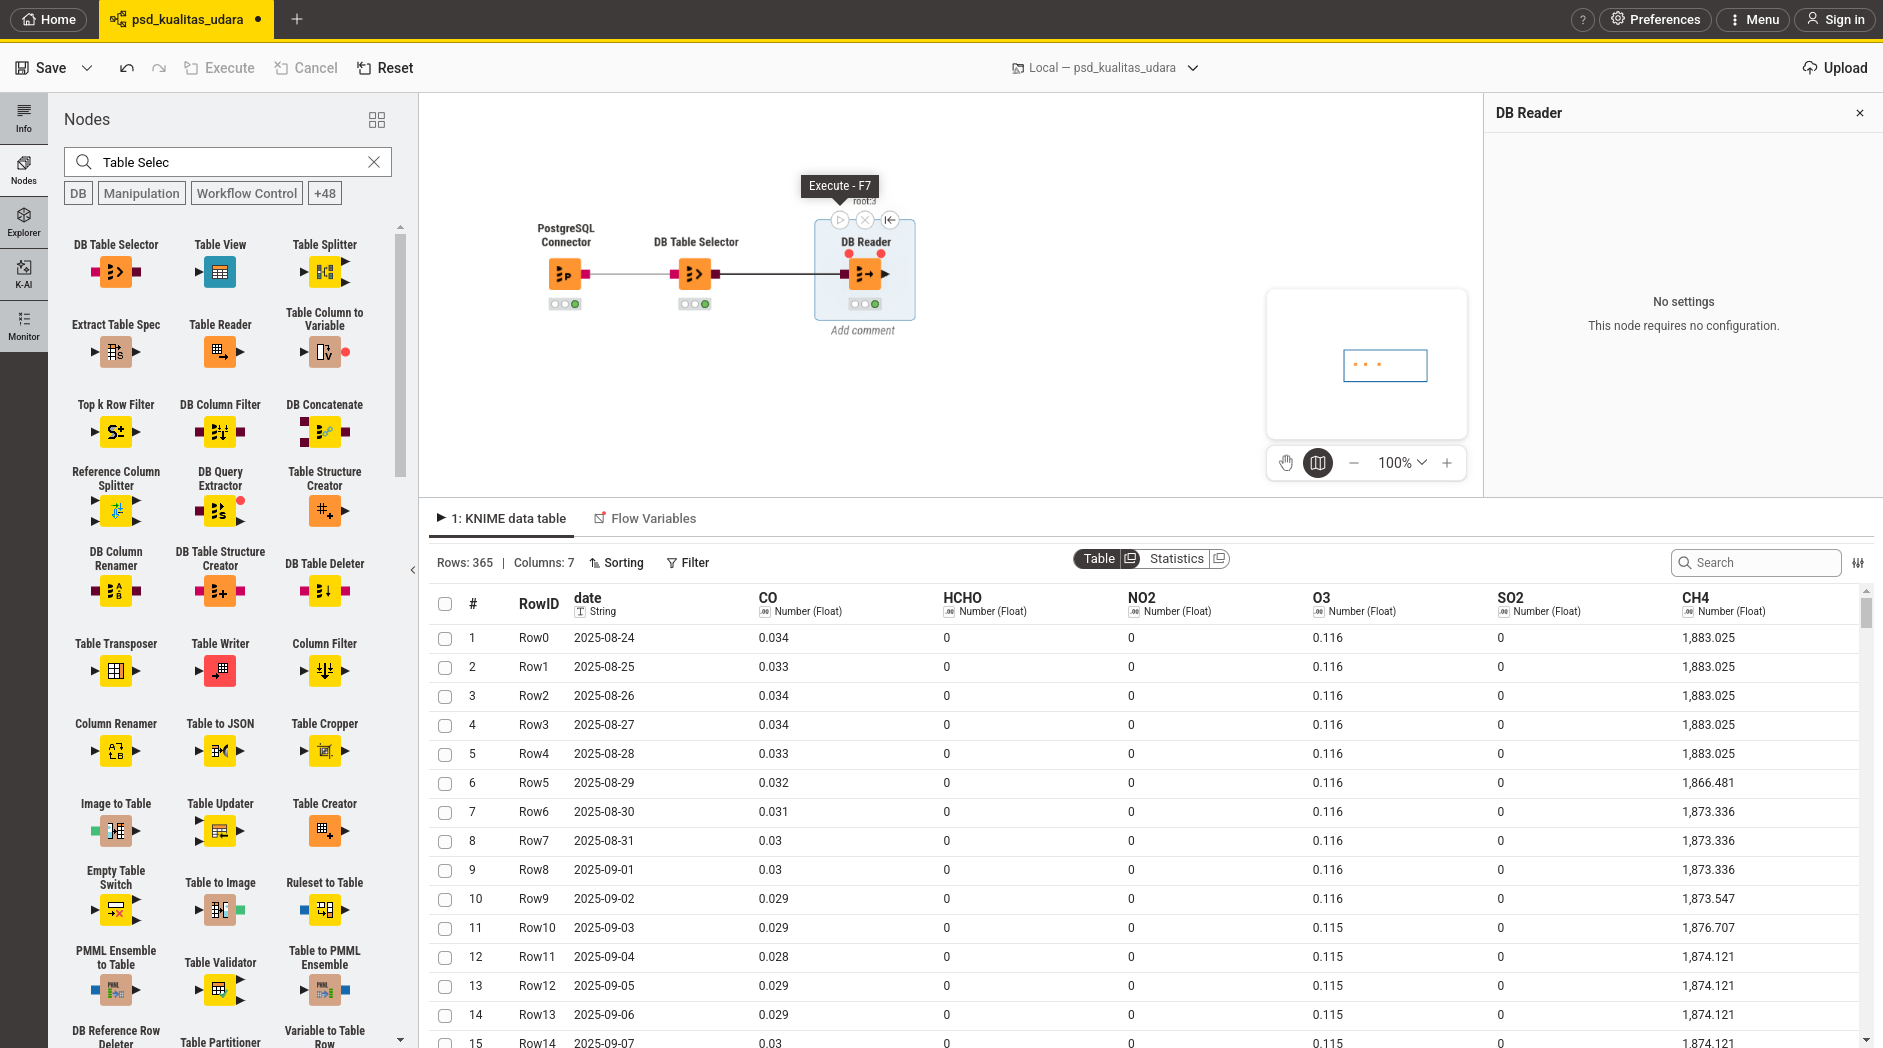

3. **Melihat Hasil Profiling Statistik Data (*Statistics Tab*)**  
   Buka panel output data (*Data Table View*) pada bagian bawah (*bottom bar*), lalu pilih tab **"Statistics"** untuk melihat ringkasan statistik deskriptif dari seluruh parameter polutan udara (`CO`, `HCHO`, `NO2`, `O3`, `SO2`, `CH4`).

   > 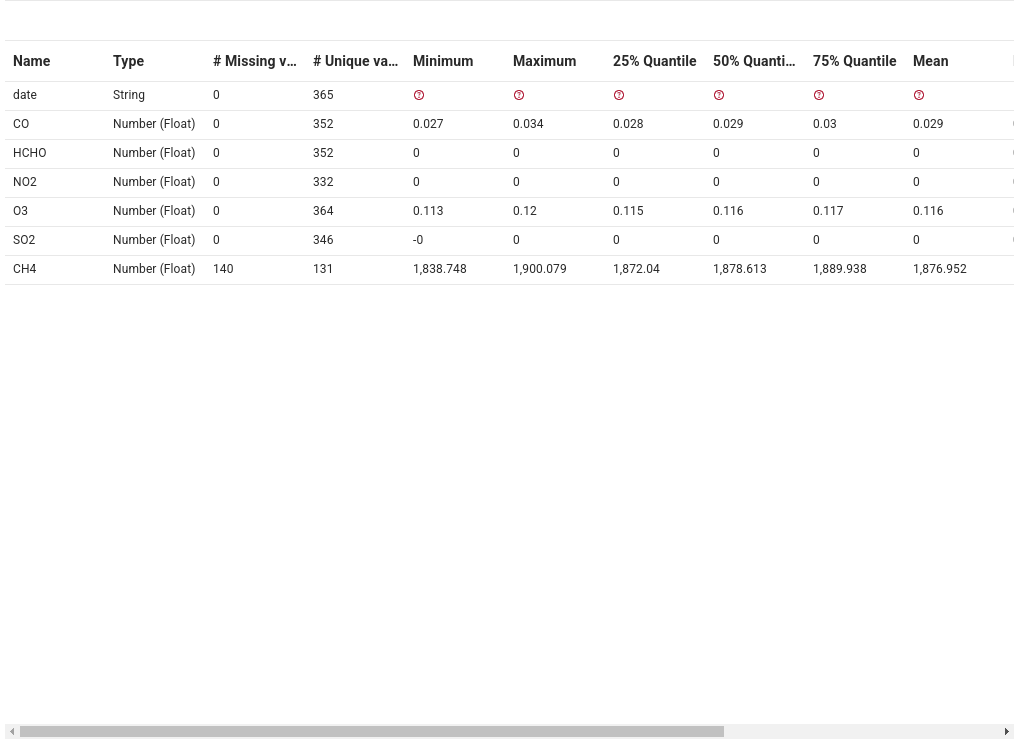


## Properti-Properti yang Ditampilkan di Statistik KNIME

### Properti Pada Statistik Dasar

Terdapat beberapa properti yang ada pada statistik dasar:

- Name
- Type
- Missing Values
- Unique Values
- Minimum
- Maximum
- 25% Quantile
- 50% Quantile
- 75% Quantile
- Mean
- Mean Absolute Deviation
- Standard Deviation
- Sum
- 10 Most Common Values

### Name

Menampilkan nama kolom/atribut dari dataset yang sedang dianalisis. Properti ini berfungsi sebagai pengenal unik untuk setiap variabel dalam tabel data, sehingga memudahkan pengguna dalam merujuk pada kolom tertentu saat melakukan manipulasi data, visualisasi, atau pemodelan.


### Type

Menunjukkan tipe data dari setiap kolom, misalnya `double` (angka desimal), `string` (teks), `integer` (bilangan bulat), atau `date`. Mengetahui tipe data sangat penting agar pengguna dapat memastikan kesesuaian data dengan operasi yang akan dilakukan, misalnya menghitung statistik deskriptif hanya pada kolom bertipe numerik.


### Missing Values

Jumlah sel/baris pada kolom yang tidak memiliki nilai (*null* atau kosong). Missing values dapat terjadi akibat ketiadaan data pengamatan pada periode tertentu, kesalahan pengambilan data, atau proses sensor yang terganggu. Kolom dengan jumlah missing values yang tinggi perlu ditangani secara hati-hati agar tidak memengaruhi keakuratan hasil analisis.


### Unique Values

Jumlah nilai yang berbeda-beda (*distinct*) pada suatu kolom. Properti ini membantu pengguna untuk memahami keragaman data dalam suatu atribut. Jika jumlah unique values sangat rendah (misalnya hanya 1), kolom tersebut bersifat konstan dan tidak memberikan informasi variabilitas yang berguna untuk analisis.


### Minimum

Nilai terkecil pada suatu kolom numerik. Minimum menunjukkan batas bawah dari rentang data yang diamati. Nilai minimum yang ekstrem (terlalu kecil atau bahkan negatif pada data yang seharusnya bernilai positif) dapat mengindikasikan adanya data pencilan (*outlier*) atau kesalahan data.


### Maximum

Nilai terbesar pada suatu kolom numerik. Maximum menunjukkan batas atas dari rentang data. Sama seperti minimum, nilai maximum yang sangat tinggi dibandingkan distribusi data lainnya dapat menandakan adanya pencilan (*outlier*) atau anomali data yang perlu ditelusuri lebih lanjut.


### 25% Quantile (Kuartil Pertama / Q1)

Nilai di mana 25% data berada di bawahnya dan 75% data berada di atasnya. Q1 digunakan untuk memahami distribusi data pada bagian bawah. Perhitungan ini merupakan salah satu komponen utama dalam pembuatan diagram kotak (*box plot*) untuk mendeteksi pencilan data.


### 50% Quantile (Median / Kuartil Kedua / Q2)

Nilai tengah dari dataset ketika data diurutkan dari terkecil hingga terbesar. Median lebih tahan terhadap pengaruh pencilan (*outlier*) dibandingkan mean, sehingga sering digunakan sebagai ukuran pusat tendensi yang lebih representatif untuk data yang distribusinya tidak simetris (*skewed*).


### 75% Quantile (Kuartil Ketiga / Q3)

Nilai di mana 75% data berada di bawahnya dan 25% data berada di atasnya. Q3 digunakan untuk memahami distribusi data pada bagian atas. Bersama dengan Q1, Q3 membentuk *Interquartile Range* (IQR = Q3 - Q1) yang merupakan ukuran sebaran data yang robust terhadap pencilan.


### Mean (Rata-rata)

Nilai rata-rata aritmatika dari seluruh data pada suatu kolom, dihitung dengan menjumlahkan seluruh nilai kemudian membaginya dengan jumlah data. Mean merupakan ukuran pusat tendensi yang paling umum digunakan, namun sensitif terhadap nilai pencilan (*outlier*). Semakin besar pencilan, semakin jauh mean akan bergeser dari nilai tengah data.


### Mean Absolute Deviation (MAD)

Rata-rata dari selisih absolut setiap data terhadap nilai mean. MAD mengukur sebaran data dengan melihat seberapa jauh rata-rata setiap titik data dari rata-rata keseluruhan. MAD lebih stabil dibandingkan standar deviasi karena tidak mengkuadratkan selisih, sehingga kurang sensitif terhadap pencilan ekstrem.


### Standard Deviation (Standar Deviasi)

Ukuran sebaran data yang menghitung akar kuadrat dari rata-rata selisih kuadrat setiap data terhadap mean (*variance*). Standar deviasi menyatakan seberapa tersebar atau bervariasinya data dari nilai rata-ratanya. Nilai standar deviasi yang kecil menunjukkan data terkonsentrasi di dekat mean, sedangkan nilai yang besar menunjukkan data sangat tersebar.


### Sum (Total Penjumlahan)

Hasil penjumlahan seluruh nilai pada suatu kolom numerik. Sum berguna untuk mengetahui total akumulasi dari data, misalnya total konsentrasi polutan tertentu selama periode pengamatan. Properti ini biasanya relevan pada kolom yang bersifat *additive* (dapat dijumlahkan secara bermakna).


### 10 Most Common Values (10 Nilai Paling Sering Muncul)

Daftar 10 nilai yang paling sering muncul (*mode*) beserta frekuensinya pada suatu kolom. Properti ini sangat berguna untuk memahami distribusi frekuensi data, terutama pada kolom kategorikal atau kolom numerik dengan sebaran nilai yang terbatas. Pada data kualitas udara, properti ini membantu mengidentifikasi rentang konsentrasi polutan yang paling umum terjadi.


## Contoh Perhitungan Manual

### Properti yang Memungkinkan

Hanya beberapa properti yang memungkinkan untuk diberi contoh perhitungan manual disini:

- 25% Quantile
- 50% Quantile
- 75% Quantile
- Mean
- Mean Absolute Deviation
- Standard Deviation
- Sum

### CO

#### 25% Quantile (Kuartil Pertama / Q1)

**Rumus**

Data diurutkan menaik terlebih dahulu:

$$x_{(1)} \le x_{(2)} \le \cdots \le x_{(365)}$$

Posisi kuartil pertama (indeks ke-$k$) dihitung dengan rumus:

$$k = (n-1)\cdot p + 1, \qquad p = 0.25$$

Jika $k$ bulat, maka $Q_1 = x_{(k)}$.

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 365$ data pengamatan:

$$k = (365-1)(0.25) + 1 = 92$$

Karena $k=92$ bulat, maka kuartil pertama adalah data terurut ke-92:

$$Q_1 = x_{(92)} = 0.0282265782718 \; \text{(mol/m²)}$$

Sebagai pemeriksaan, nilai terurut di sekitar posisi tersebut:

- $x_{(91)} = 0.028224842214$
- $x_{(92)} = 0.0282265782718$ ← **nilai Q1**
- $x_{(93)} = 0.0282400433637$


#### 50% Quantile (Median / Kuartil Kedua / Q2)

**Rumus**

Data diurutkan menaik terlebih dahulu:

$$x_{(1)} \le x_{(2)} \le \cdots \le x_{(365)}$$

Posisi median (indeks ke-$k$) dihitung dengan rumus:

$$k = (n-1)\cdot p + 1, \qquad p = 0.50$$

Jika $k$ bulat, maka $Q_2 = x_{(k)}$.

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 365$ data pengamatan:

$$k = (365-1)(0.50) + 1 = 183$$

Karena $k=183$ bulat, maka median adalah data terurut ke-183:

$$Q_2 = x_{(183)} = 0.0292928170365 \; \text{(mol/m²)}$$

Sebagai pemeriksaan, nilai terurut di sekitar posisi tersebut:

- $x_{(182)} = 0.0292744462067$
- $x_{(183)} = 0.0292928170365$ ← **nilai Q2 / median**
- $x_{(184)} = 0.0293023495946$


#### 75% Quantile (Kuartil Ketiga / Q3)

**Rumus**

Data diurutkan menaik terlebih dahulu:

$$x_{(1)} \le x_{(2)} \le \cdots \le x_{(365)}$$

Posisi kuartil ketiga (indeks ke-$k$) dihitung dengan rumus:

$$k = (n-1)\cdot p + 1, \qquad p = 0.75$$

Jika $k$ bulat, maka $Q_3 = x_{(k)}$.

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 365$ data pengamatan:

$$k = (365-1)(0.75) + 1 = 274$$

Karena $k=274$ bulat, maka kuartil ketiga adalah data terurut ke-274:

$$Q_3 = x_{(274)} = 0.030195770976 \; \text{(mol/m²)}$$

Sebagai pemeriksaan, nilai terurut di sekitar posisi tersebut:

- $x_{(273)} = 0.0301592673377$
- $x_{(274)} = 0.030195770976$ ← **nilai Q3**
- $x_{(275)} = 0.0302500742003$


#### Mean (Rata-rata)

**Rumus**

$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i = \frac{x_1 + x_2 + \cdots + x_n}{n}$$

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 365$ data pengamatan, jumlah seluruh nilai adalah:

$$\sum_{i=1}^{365} x_i = 10.7270442103$$

Sehingga rata-ratanya:

$$\bar{x} = \frac{10.7270442103}{365} = 0.0293891622201 \; \text{(mol/m²)}$$


#### Mean Absolute Deviation (MAD)

**Rumus**

$$\text{MAD} = \frac{1}{n}\sum_{i=1}^{n} |x_i - \bar{x}|$$

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 365$ dan nilai rata-rata:

$$\bar{x} = 0.0293891622201$$

Jumlah seluruh selisih absolut data terhadap rata-rata:

$$\sum_{i=1}^{365} |x_i - \bar{x}| = 0.429803734753$$

Sehingga nilai MAD:

$$\text{MAD} = \frac{0.429803734753}{365} = 0.00117754447878 \; \text{(mol/m²)}$$


#### Standard Deviation (Standar Deviasi)

**Rumus**

$$s = \sqrt{\frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}}$$

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 365$ dan nilai rata-rata:

$$\bar{x} = 0.0293891622201$$

Jumlah kuadrat selisih data terhadap rata-rata:

$$\sum_{i=1}^{365} (x_i - \bar{x})^2 = 0.00075919039648$$

Varians sampel:

$$s^2 = \frac{0.00075919039648}{365-1} = 2.08568790242e-06$$

Standar deviasi (akar kuadrat varians):

$$s = \sqrt{2.08568790242e-06} = 0.0014441910893 \; \text{(mol/m²)}$$


#### Sum (Total Penjumlahan)

**Rumus**

$$\text{Sum} = \sum_{i=1}^{n} x_i = x_1 + x_2 + \cdots + x_n$$

**Perhitungan Manual dengan Data Aktual**

Menjumlahkan seluruh nilai pengamatan ($n = 365$):

$$\sum_{i=1}^{365} x_i = 10.7270442103 \; \text{(mol/m²)}$$


### HCHO

#### 25% Quantile (Kuartil Pertama / Q1)

**Rumus**

Data diurutkan menaik terlebih dahulu:

$$x_{(1)} \le x_{(2)} \le \cdots \le x_{(365)}$$

Posisi kuartil pertama (indeks ke-$k$) dihitung dengan rumus:

$$k = (n-1)\cdot p + 1, \qquad p = 0.25$$

Jika $k$ bulat, maka $Q_1 = x_{(k)}$.

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 365$ data pengamatan:

$$k = (365-1)(0.25) + 1 = 92$$

Karena $k=92$ bulat, maka kuartil pertama adalah data terurut ke-92:

$$Q_1 = x_{(92)} = 0.000160025389654 \; \text{(mol/m²)}$$

Sebagai pemeriksaan, nilai terurut di sekitar posisi tersebut:

- $x_{(91)} = 0.000160010343625$
- $x_{(92)} = 0.000160025389654$ ← **nilai Q1**
- $x_{(93)} = 0.000160053872649$


#### 50% Quantile (Median / Kuartil Kedua / Q2)

**Rumus**

Data diurutkan menaik terlebih dahulu:

$$x_{(1)} \le x_{(2)} \le \cdots \le x_{(365)}$$

Posisi median (indeks ke-$k$) dihitung dengan rumus:

$$k = (n-1)\cdot p + 1, \qquad p = 0.50$$

Jika $k$ bulat, maka $Q_2 = x_{(k)}$.

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 365$ data pengamatan:

$$k = (365-1)(0.50) + 1 = 183$$

Karena $k=183$ bulat, maka median adalah data terurut ke-183:

$$Q_2 = x_{(183)} = 0.000167117351818 \; \text{(mol/m²)}$$

Sebagai pemeriksaan, nilai terurut di sekitar posisi tersebut:

- $x_{(182)} = 0.000167081973763$
- $x_{(183)} = 0.000167117351818$ ← **nilai Q2 / median**
- $x_{(184)} = 0.000167333226866$


#### 75% Quantile (Kuartil Ketiga / Q3)

**Rumus**

Data diurutkan menaik terlebih dahulu:

$$x_{(1)} \le x_{(2)} \le \cdots \le x_{(365)}$$

Posisi kuartil ketiga (indeks ke-$k$) dihitung dengan rumus:

$$k = (n-1)\cdot p + 1, \qquad p = 0.75$$

Jika $k$ bulat, maka $Q_3 = x_{(k)}$.

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 365$ data pengamatan:

$$k = (365-1)(0.75) + 1 = 274$$

Karena $k=274$ bulat, maka kuartil ketiga adalah data terurut ke-274:

$$Q_3 = x_{(274)} = 0.000180683687837 \; \text{(mol/m²)}$$

Sebagai pemeriksaan, nilai terurut di sekitar posisi tersebut:

- $x_{(273)} = 0.000180345236441$
- $x_{(274)} = 0.000180683687837$ ← **nilai Q3**
- $x_{(275)} = 0.000180711010292$


#### Mean (Rata-rata)

**Rumus**

$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i = \frac{x_1 + x_2 + \cdots + x_n}{n}$$

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 365$ data pengamatan, jumlah seluruh nilai adalah:

$$\sum_{i=1}^{365} x_i = 0.0647298519842$$

Sehingga rata-ratanya:

$$\bar{x} = \frac{0.0647298519842}{365} = 0.000177342060231 \; \text{(mol/m²)}$$


#### Mean Absolute Deviation (MAD)

**Rumus**

$$\text{MAD} = \frac{1}{n}\sum_{i=1}^{n} |x_i - \bar{x}|$$

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 365$ dan nilai rata-rata:

$$\bar{x} = 0.000177342060231$$

Jumlah seluruh selisih absolut data terhadap rata-rata:

$$\sum_{i=1}^{365} |x_i - \bar{x}| = 0.00903260943598$$

Sehingga nilai MAD:

$$\text{MAD} = \frac{0.00903260943598}{365} = 2.47468751671e-05 \; \text{(mol/m²)}$$


#### Standard Deviation (Standar Deviasi)

**Rumus**

$$s = \sqrt{\frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}}$$

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 365$ dan nilai rata-rata:

$$\bar{x} = 0.000177342060231$$

Jumlah kuadrat selisih data terhadap rata-rata:

$$\sum_{i=1}^{365} (x_i - \bar{x})^2 = 5.93572224077e-07$$

Varians sampel:

$$s^2 = \frac{5.93572224077e-07}{365-1} = 1.63069292329e-09$$

Standar deviasi (akar kuadrat varians):

$$s = \sqrt{1.63069292329e-09} = 4.0381839028e-05 \; \text{(mol/m²)}$$


#### Sum (Total Penjumlahan)

**Rumus**

$$\text{Sum} = \sum_{i=1}^{n} x_i = x_1 + x_2 + \cdots + x_n$$

**Perhitungan Manual dengan Data Aktual**

Menjumlahkan seluruh nilai pengamatan ($n = 365$):

$$\sum_{i=1}^{365} x_i = 0.0647298519842 \; \text{(mol/m²)}$$


### NO2

#### 25% Quantile (Kuartil Pertama / Q1)

**Rumus**

Data diurutkan menaik terlebih dahulu:

$$x_{(1)} \le x_{(2)} \le \cdots \le x_{(365)}$$

Posisi kuartil pertama (indeks ke-$k$) dihitung dengan rumus:

$$k = (n-1)\cdot p + 1, \qquad p = 0.25$$

Jika $k$ bulat, maka $Q_1 = x_{(k)}$.

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 365$ data pengamatan:

$$k = (365-1)(0.25) + 1 = 92$$

Karena $k=92$ bulat, maka kuartil pertama adalah data terurut ke-92:

$$Q_1 = x_{(92)} = 3.50500161113e-05 \; \text{(mol/m²)}$$

Sebagai pemeriksaan, nilai terurut di sekitar posisi tersebut:

- $x_{(91)} = 3.50402659793e-05$
- $x_{(92)} = 3.50500161113e-05$ ← **nilai Q1**
- $x_{(93)} = 3.50500161113e-05$


#### 50% Quantile (Median / Kuartil Kedua / Q2)

**Rumus**

Data diurutkan menaik terlebih dahulu:

$$x_{(1)} \le x_{(2)} \le \cdots \le x_{(365)}$$

Posisi median (indeks ke-$k$) dihitung dengan rumus:

$$k = (n-1)\cdot p + 1, \qquad p = 0.50$$

Jika $k$ bulat, maka $Q_2 = x_{(k)}$.

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 365$ data pengamatan:

$$k = (365-1)(0.50) + 1 = 183$$

Karena $k=183$ bulat, maka median adalah data terurut ke-183:

$$Q_2 = x_{(183)} = 3.82021690134e-05 \; \text{(mol/m²)}$$

Sebagai pemeriksaan, nilai terurut di sekitar posisi tersebut:

- $x_{(182)} = 3.82003626356e-05$
- $x_{(183)} = 3.82021690134e-05$ ← **nilai Q2 / median**
- $x_{(184)} = 3.82213657907e-05$


#### 75% Quantile (Kuartil Ketiga / Q3)

**Rumus**

Data diurutkan menaik terlebih dahulu:

$$x_{(1)} \le x_{(2)} \le \cdots \le x_{(365)}$$

Posisi kuartil ketiga (indeks ke-$k$) dihitung dengan rumus:

$$k = (n-1)\cdot p + 1, \qquad p = 0.75$$

Jika $k$ bulat, maka $Q_3 = x_{(k)}$.

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 365$ data pengamatan:

$$k = (365-1)(0.75) + 1 = 274$$

Karena $k=274$ bulat, maka kuartil ketiga adalah data terurut ke-274:

$$Q_3 = x_{(274)} = 4.32032001782e-05 \; \text{(mol/m²)}$$

Sebagai pemeriksaan, nilai terurut di sekitar posisi tersebut:

- $x_{(273)} = 4.31848946659e-05$
- $x_{(274)} = 4.32032001782e-05$ ← **nilai Q3**
- $x_{(275)} = 4.32325935335e-05$


#### Mean (Rata-rata)

**Rumus**

$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i = \frac{x_1 + x_2 + \cdots + x_n}{n}$$

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 365$ data pengamatan, jumlah seluruh nilai adalah:

$$\sum_{i=1}^{365} x_i = 0.014358209608$$

Sehingga rata-ratanya:

$$\bar{x} = \frac{0.014358209608}{365} = 3.933756057e-05 \; \text{(mol/m²)}$$


#### Mean Absolute Deviation (MAD)

**Rumus**

$$\text{MAD} = \frac{1}{n}\sum_{i=1}^{n} |x_i - \bar{x}|$$

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 365$ dan nilai rata-rata:

$$\bar{x} = 3.933756057e-05$$

Jumlah seluruh selisih absolut data terhadap rata-rata:

$$\sum_{i=1}^{365} |x_i - \bar{x}| = 0.00169628171449$$

Sehingga nilai MAD:

$$\text{MAD} = \frac{0.00169628171449}{365} = 4.647347163e-06 \; \text{(mol/m²)}$$


#### Standard Deviation (Standar Deviasi)

**Rumus**

$$s = \sqrt{\frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}}$$

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 365$ dan nilai rata-rata:

$$\bar{x} = 3.933756057e-05$$

Jumlah kuadrat selisih data terhadap rata-rata:

$$\sum_{i=1}^{365} (x_i - \bar{x})^2 = 1.17906698863e-08$$

Varians sampel:

$$s^2 = \frac{1.17906698863e-08}{365-1} = 3.23919502372e-11$$

Standar deviasi (akar kuadrat varians):

$$s = \sqrt{3.23919502372e-11} = 5.69139264479e-06 \; \text{(mol/m²)}$$


#### Sum (Total Penjumlahan)

**Rumus**

$$\text{Sum} = \sum_{i=1}^{n} x_i = x_1 + x_2 + \cdots + x_n$$

**Perhitungan Manual dengan Data Aktual**

Menjumlahkan seluruh nilai pengamatan ($n = 365$):

$$\sum_{i=1}^{365} x_i = 0.014358209608 \; \text{(mol/m²)}$$


### O3

#### 25% Quantile (Kuartil Pertama / Q1)

**Rumus**

Data diurutkan menaik terlebih dahulu:

$$x_{(1)} \le x_{(2)} \le \cdots \le x_{(365)}$$

Posisi kuartil pertama (indeks ke-$k$) dihitung dengan rumus:

$$k = (n-1)\cdot p + 1, \qquad p = 0.25$$

Jika $k$ bulat, maka $Q_1 = x_{(k)}$.

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 365$ data pengamatan:

$$k = (365-1)(0.25) + 1 = 92$$

Karena $k=92$ bulat, maka kuartil pertama adalah data terurut ke-92:

$$Q_1 = x_{(92)} = 0.114737772562 \; \text{(mol/m²)}$$

Sebagai pemeriksaan, nilai terurut di sekitar posisi tersebut:

- $x_{(91)} = 0.11471376913$
- $x_{(92)} = 0.114737772562$ ← **nilai Q1**
- $x_{(93)} = 0.114738966527$


#### 50% Quantile (Median / Kuartil Kedua / Q2)

**Rumus**

Data diurutkan menaik terlebih dahulu:

$$x_{(1)} \le x_{(2)} \le \cdots \le x_{(365)}$$

Posisi median (indeks ke-$k$) dihitung dengan rumus:

$$k = (n-1)\cdot p + 1, \qquad p = 0.50$$

Jika $k$ bulat, maka $Q_2 = x_{(k)}$.

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 365$ data pengamatan:

$$k = (365-1)(0.50) + 1 = 183$$

Karena $k=183$ bulat, maka median adalah data terurut ke-183:

$$Q_2 = x_{(183)} = 0.115882079022 \; \text{(mol/m²)}$$

Sebagai pemeriksaan, nilai terurut di sekitar posisi tersebut:

- $x_{(182)} = 0.115841559297$
- $x_{(183)} = 0.115882079022$ ← **nilai Q2 / median**
- $x_{(184)} = 0.115882180767$


#### 75% Quantile (Kuartil Ketiga / Q3)

**Rumus**

Data diurutkan menaik terlebih dahulu:

$$x_{(1)} \le x_{(2)} \le \cdots \le x_{(365)}$$

Posisi kuartil ketiga (indeks ke-$k$) dihitung dengan rumus:

$$k = (n-1)\cdot p + 1, \qquad p = 0.75$$

Jika $k$ bulat, maka $Q_3 = x_{(k)}$.

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 365$ data pengamatan:

$$k = (365-1)(0.75) + 1 = 274$$

Karena $k=274$ bulat, maka kuartil ketiga adalah data terurut ke-274:

$$Q_3 = x_{(274)} = 0.116644143594 \; \text{(mol/m²)}$$

Sebagai pemeriksaan, nilai terurut di sekitar posisi tersebut:

- $x_{(273)} = 0.116641464544$
- $x_{(274)} = 0.116644143594$ ← **nilai Q3**
- $x_{(275)} = 0.116649702628$


#### Mean (Rata-rata)

**Rumus**

$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i = \frac{x_1 + x_2 + \cdots + x_n}{n}$$

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 365$ data pengamatan, jumlah seluruh nilai adalah:

$$\sum_{i=1}^{365} x_i = 42.2267412137$$

Sehingga rata-ratanya:

$$\bar{x} = \frac{42.2267412137}{365} = 0.115689701955 \; \text{(mol/m²)}$$


#### Mean Absolute Deviation (MAD)

**Rumus**

$$\text{MAD} = \frac{1}{n}\sum_{i=1}^{n} |x_i - \bar{x}|$$

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 365$ dan nilai rata-rata:

$$\bar{x} = 0.115689701955$$

Jumlah seluruh selisih absolut data terhadap rata-rata:

$$\sum_{i=1}^{365} |x_i - \bar{x}| = 0.424904388113$$

Sehingga nilai MAD:

$$\text{MAD} = \frac{0.424904388113}{365} = 0.00116412161127 \; \text{(mol/m²)}$$


#### Standard Deviation (Standar Deviasi)

**Rumus**

$$s = \sqrt{\frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}}$$

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 365$ dan nilai rata-rata:

$$\bar{x} = 0.115689701955$$

Jumlah kuadrat selisih data terhadap rata-rata:

$$\sum_{i=1}^{365} (x_i - \bar{x})^2 = 0.000728979589354$$

Varians sampel:

$$s^2 = \frac{0.000728979589354}{365-1} = 2.00269117954e-06$$

Standar deviasi (akar kuadrat varians):

$$s = \sqrt{2.00269117954e-06} = 0.00141516471817 \; \text{(mol/m²)}$$


#### Sum (Total Penjumlahan)

**Rumus**

$$\text{Sum} = \sum_{i=1}^{n} x_i = x_1 + x_2 + \cdots + x_n$$

**Perhitungan Manual dengan Data Aktual**

Menjumlahkan seluruh nilai pengamatan ($n = 365$):

$$\sum_{i=1}^{365} x_i = 42.2267412137 \; \text{(mol/m²)}$$


### SO2

#### 25% Quantile (Kuartil Pertama / Q1)

**Rumus**

Data diurutkan menaik terlebih dahulu:

$$x_{(1)} \le x_{(2)} \le \cdots \le x_{(365)}$$

Posisi kuartil pertama (indeks ke-$k$) dihitung dengan rumus:

$$k = (n-1)\cdot p + 1, \qquad p = 0.25$$

Jika $k$ bulat, maka $Q_1 = x_{(k)}$.

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 365$ data pengamatan:

$$k = (365-1)(0.25) + 1 = 92$$

Karena $k=92$ bulat, maka kuartil pertama adalah data terurut ke-92:

$$Q_1 = x_{(92)} = 4.502086253e-05 \; \text{(mol/m²)}$$

Sebagai pemeriksaan, nilai terurut di sekitar posisi tersebut:

- $x_{(91)} = 4.46749795039e-05$
- $x_{(92)} = 4.502086253e-05$ ← **nilai Q1**
- $x_{(93)} = 4.50382700015e-05$


#### 50% Quantile (Median / Kuartil Kedua / Q2)

**Rumus**

Data diurutkan menaik terlebih dahulu:

$$x_{(1)} \le x_{(2)} \le \cdots \le x_{(365)}$$

Posisi median (indeks ke-$k$) dihitung dengan rumus:

$$k = (n-1)\cdot p + 1, \qquad p = 0.50$$

Jika $k$ bulat, maka $Q_2 = x_{(k)}$.

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 365$ data pengamatan:

$$k = (365-1)(0.50) + 1 = 183$$

Karena $k=183$ bulat, maka median adalah data terurut ke-183:

$$Q_2 = x_{(183)} = 0.000114134865547 \; \text{(mol/m²)}$$

Sebagai pemeriksaan, nilai terurut di sekitar posisi tersebut:

- $x_{(182)} = 0.00011345335086$
- $x_{(183)} = 0.000114134865547$ ← **nilai Q2 / median**
- $x_{(184)} = 0.000114169955694$


#### 75% Quantile (Kuartil Ketiga / Q3)

**Rumus**

Data diurutkan menaik terlebih dahulu:

$$x_{(1)} \le x_{(2)} \le \cdots \le x_{(365)}$$

Posisi kuartil ketiga (indeks ke-$k$) dihitung dengan rumus:

$$k = (n-1)\cdot p + 1, \qquad p = 0.75$$

Jika $k$ bulat, maka $Q_3 = x_{(k)}$.

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 365$ data pengamatan:

$$k = (365-1)(0.75) + 1 = 274$$

Karena $k=274$ bulat, maka kuartil ketiga adalah data terurut ke-274:

$$Q_3 = x_{(274)} = 0.000171179380942 \; \text{(mol/m²)}$$

Sebagai pemeriksaan, nilai terurut di sekitar posisi tersebut:

- $x_{(273)} = 0.000170124009017$
- $x_{(274)} = 0.000171179380942$ ← **nilai Q3**
- $x_{(275)} = 0.000171895932468$


#### Mean (Rata-rata)

**Rumus**

$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i = \frac{x_1 + x_2 + \cdots + x_n}{n}$$

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 365$ data pengamatan, jumlah seluruh nilai adalah:

$$\sum_{i=1}^{365} x_i = 0.0412158574029$$

Sehingga rata-ratanya:

$$\bar{x} = \frac{0.0412158574029}{365} = 0.000112920157268 \; \text{(mol/m²)}$$


#### Mean Absolute Deviation (MAD)

**Rumus**

$$\text{MAD} = \frac{1}{n}\sum_{i=1}^{n} |x_i - \bar{x}|$$

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 365$ dan nilai rata-rata:

$$\bar{x} = 0.000112920157268$$

Jumlah seluruh selisih absolut data terhadap rata-rata:

$$\sum_{i=1}^{365} |x_i - \bar{x}| = 0.0224832618311$$

Sehingga nilai MAD:

$$\text{MAD} = \frac{0.0224832618311}{365} = 6.15979776195e-05 \; \text{(mol/m²)}$$


#### Standard Deviation (Standar Deviasi)

**Rumus**

$$s = \sqrt{\frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}}$$

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 365$ dan nilai rata-rata:

$$\bar{x} = 0.000112920157268$$

Jumlah kuadrat selisih data terhadap rata-rata:

$$\sum_{i=1}^{365} (x_i - \bar{x})^2 = 1.89027874672e-06$$

Varians sampel:

$$s^2 = \frac{1.89027874672e-06}{365-1} = 5.19307348001e-09$$

Standar deviasi (akar kuadrat varians):

$$s = \sqrt{5.19307348001e-09} = 7.20629827304e-05 \; \text{(mol/m²)}$$


#### Sum (Total Penjumlahan)

**Rumus**

$$\text{Sum} = \sum_{i=1}^{n} x_i = x_1 + x_2 + \cdots + x_n$$

**Perhitungan Manual dengan Data Aktual**

Menjumlahkan seluruh nilai pengamatan ($n = 365$):

$$\sum_{i=1}^{365} x_i = 0.0412158574029 \; \text{(mol/m²)}$$


### CH4

#### 25% Quantile (Kuartil Pertama / Q1)

Catatan: kolom memiliki 140 baris kosong (_missing values_), sehingga perhitungan hanya menggunakan 225 data yang tersedia.


**Rumus**

Data diurutkan menaik terlebih dahulu:

$$x_{(1)} \le x_{(2)} \le \cdots \le x_{(225)}$$

Posisi kuartil pertama (indeks ke-$k$) dihitung dengan rumus:

$$k = (n-1)\cdot p + 1, \qquad p = 0.25$$

Jika $k$ bulat, maka $Q_1 = x_{(k)}$.

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 225$ data pengamatan:

$$k = (225-1)(0.25) + 1 = 57$$

Karena $k=57$ bulat, maka kuartil pertama adalah data terurut ke-57:

$$Q_1 = x_{(57)} = 1872.03971352 \; \text{(ppb)}$$

Sebagai pemeriksaan, nilai terurut di sekitar posisi tersebut:

- $x_{(56)} = 1872.03971352$
- $x_{(57)} = 1872.03971352$ ← **nilai Q1**
- $x_{(58)} = 1872.03971352$


#### 50% Quantile (Median / Kuartil Kedua / Q2)

Catatan: kolom memiliki 140 baris kosong (_missing values_), sehingga perhitungan hanya menggunakan 225 data yang tersedia.


**Rumus**

Data diurutkan menaik terlebih dahulu:

$$x_{(1)} \le x_{(2)} \le \cdots \le x_{(225)}$$

Posisi median (indeks ke-$k$) dihitung dengan rumus:

$$k = (n-1)\cdot p + 1, \qquad p = 0.50$$

Jika $k$ bulat, maka $Q_2 = x_{(k)}$.

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 225$ data pengamatan:

$$k = (225-1)(0.50) + 1 = 113$$

Karena $k=113$ bulat, maka median adalah data terurut ke-113:

$$Q_2 = x_{(113)} = 1878.61347284 \; \text{(ppb)}$$

Sebagai pemeriksaan, nilai terurut di sekitar posisi tersebut:

- $x_{(112)} = 1878.61347284$
- $x_{(113)} = 1878.61347284$ ← **nilai Q2 / median**
- $x_{(114)} = 1878.61347284$


#### 75% Quantile (Kuartil Ketiga / Q3)

Catatan: kolom memiliki 140 baris kosong (_missing values_), sehingga perhitungan hanya menggunakan 225 data yang tersedia.


**Rumus**

Data diurutkan menaik terlebih dahulu:

$$x_{(1)} \le x_{(2)} \le \cdots \le x_{(225)}$$

Posisi kuartil ketiga (indeks ke-$k$) dihitung dengan rumus:

$$k = (n-1)\cdot p + 1, \qquad p = 0.75$$

Jika $k$ bulat, maka $Q_3 = x_{(k)}$.

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 225$ data pengamatan:

$$k = (225-1)(0.75) + 1 = 169$$

Karena $k=169$ bulat, maka kuartil ketiga adalah data terurut ke-169:

$$Q_3 = x_{(169)} = 1889.29831873 \; \text{(ppb)}$$

Sebagai pemeriksaan, nilai terurut di sekitar posisi tersebut:

- $x_{(168)} = 1889.29831873$
- $x_{(169)} = 1889.29831873$ ← **nilai Q3**
- $x_{(170)} = 1890.57735945$


#### Mean (Rata-rata)

Catatan: kolom memiliki 140 baris kosong (_missing values_), sehingga perhitungan hanya menggunakan 225 data yang tersedia.


**Rumus**

$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i = \frac{x_1 + x_2 + \cdots + x_n}{n}$$

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 225$ data pengamatan, jumlah seluruh nilai adalah:

$$\sum_{i=1}^{225} x_i = 422314.107838$$

Sehingga rata-ratanya:

$$\bar{x} = \frac{422314.107838}{225} = 1876.95159039 \; \text{(ppb)}$$


#### Mean Absolute Deviation (MAD)

Catatan: kolom memiliki 140 baris kosong (_missing values_), sehingga perhitungan hanya menggunakan 225 data yang tersedia.


**Rumus**

$$\text{MAD} = \frac{1}{n}\sum_{i=1}^{n} |x_i - \bar{x}|$$

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 225$ dan nilai rata-rata:

$$\bar{x} = 1876.95159039$$

Jumlah seluruh selisih absolut data terhadap rata-rata:

$$\sum_{i=1}^{225} |x_i - \bar{x}| = 2694.40302509$$

Sehingga nilai MAD:

$$\text{MAD} = \frac{2694.40302509}{225} = 11.975124556 \; \text{(ppb)}$$


#### Standard Deviation (Standar Deviasi)

Catatan: kolom memiliki 140 baris kosong (_missing values_), sehingga perhitungan hanya menggunakan 225 data yang tersedia.


**Rumus**

$$s = \sqrt{\frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}}$$

**Perhitungan Manual dengan Data Aktual**

Dengan $n = 225$ dan nilai rata-rata:

$$\bar{x} = 1876.95159039$$

Jumlah kuadrat selisih data terhadap rata-rata:

$$\sum_{i=1}^{225} (x_i - \bar{x})^2 = 51714.6171487$$

Varians sampel:

$$s^2 = \frac{51714.6171487}{225-1} = 230.868826557$$

Standar deviasi (akar kuadrat varians):

$$s = \sqrt{230.868826557} = 15.1943682513 \; \text{(ppb)}$$


#### Sum (Total Penjumlahan)

Catatan: kolom memiliki 140 baris kosong (_missing values_), sehingga perhitungan hanya menggunakan 225 data yang tersedia.


**Rumus**

$$\text{Sum} = \sum_{i=1}^{n} x_i = x_1 + x_2 + \cdots + x_n$$

**Perhitungan Manual dengan Data Aktual**

Menjumlahkan seluruh nilai pengamatan ($n = 225$):

$$\sum_{i=1}^{225} x_i = 422314.107838 \; \text{(ppb)}$$
